# Explarotary Data Analysis & Confirmatory Data Analysis

## Description of Variables

### URL Features
*   **TLD**: The Top Level Domain (e.g., .com or .edu), which is the last part of the domain name.
*   **URLLength**: The total length of the URL, which is often longer in phishing attacks due to added subdirectories or parameters.
*   **IsDomainIP**: A binary feature indicating if the URL uses an IP address instead of a domain name.
*   **NoOfSubDomain**: The count of subdomains appearing before the domain name, often used to mimic legitimate sites.
*   **NoOfObfuscatedChar**: The count of obfuscated characters (e.g., using hex encoding like `%6d`) in the URL.
*   **IsHTTPS**: A feature indicating if the webpage uses the secured HTTPS protocol or unsecured HTTP.
*   **NoOfDigits**: The count of digits present in the URL.
*   **NoOfEquals**: The count of equal signs (`=`) in the URL.
*   **NoOfQMark**: The count of question marks (`?`) in the URL.
*   **NoOfAmp**: The count of ampersand or percent symbols in the URL.

### HTML Features
*   **LargestLineLength**: The length of the longest line of code in the HTML, used to detect code obfuscation.
*   **HasTitle**: A boolean indicating if the webpage contains a title tag.
*   **HasFavicon**: A boolean indicating if the website logo is included in the favicon tag.
*   **IsResponsive**: A feature indicating if the webpage is responsive and adapts across different devices.
*   **NoOfURLRedirect**: The count of redirects found in the HTML code (e.g., using `window.location` or `refresh` tags).
*   **HasDescription**: A boolean indicating if the webpage provides a description using the `description` meta name.
*   **NoOfPopup**: The count of pop-up windows (e.g., `window.open`) used on the page.
*   **NoOfiFrame**: The count of `iframe` tags, which are often used to capture sensitive information.
*   **HasExternalFormSubmit**: A feature indicating if an HTML form submits data to an external URL.
*   **HasCopyrightInfo**: A feature indicating the presence of copyright information on the webpage.
*   **HasSocialNet**: A feature indicating the presence of social networking links or information.
*   **HasPasswordField**: A boolean indicating the presence of password entry fields in the HTML.
*   **HasSubmitButton**: A boolean indicating the presence of a submit button tag.
*   **HasHiddenFields**: A feature indicating the use of hidden fields to capture information without user knowledge.
*   **Bank, Pay, Crypto**: Features indicating the presence of terms related to financial transactions or cryptocurrency, suggesting a request for sensitive financial info.
*   **NoOfImage**: The count of images used on the webpage.
*   **NoOfJS**: The count of JavaScript blocks embedded in the HTML.
*   **NoOfSelfRef**: The count of hyperlinks that navigate to the same webpage.
*   **NoOfSelfRedirect**: The number of times a webpage automatically reloads or redirects to the same URL.
*   **NoOfEmptyRef**: The count of hyperlinks that navigate to empty links.
*   **NoOfExternalRef**: The count of hyperlinks that navigate to external webpages.

### Derived Features
*   **CharContinuationRate**: A ratio calculated by summing the longest sequences of alphabets, digits, and special characters, divided by the total URL length.
*   **URLTitleMatchScore**: A score (0 to 100) indicating the discrepancy between the URL and the webpage title; a lower score may indicate phishing.
*   **URLCharProb**: A probability calculation based on the frequency of specific characters and digits in the URL compared to patterns in legitimate and phishing datasets.
*   **TLDLegitimateProb**: A probability ratio indicating how commonly the URL's TLD is associated with legitimate websites.

### Target Variable
*   **label**: The classification target where `1` represents a legitimate URL and `0` represents a phishing URL.

First Steps...

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [37]:
df = pd.read_csv('Phishing_URL_ds_5percent_missing_train.csv')

In [38]:
with pd.option_context("display.max_columns", None):
    display(df.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,is_title_empty,label
0,https://www.dotwhat.net,22.0,www.dotwhat.net,15.0,0.0,net,100.000000,1.000000,0.038420,0.056222,3.0,1.0,0.0,0.0,0.0,9.0,0.409,0.0,0.0,0.0,0.0,0.0,1.0,0.045,1.0,219.0,927.0,NaN,100.0,100.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,31.0,NaN,6.0,36.0,0.0,2.0,0,1
1,https://sg-dbs.life/,20.0,sg-dbs.life,11.0,0.0,life,70.523416,0.666667,0.000255,0.044765,4.0,0.0,NaN,0.0,0.0,9.0,0.450,0.0,0.0,0.0,0.0,0.0,3.0,0.150,1.0,205.0,91.0,1.0,100.0,100.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,5.0,2.0,4.0,0.0,0.0,0.0,0,0
2,https://www.monseratdelucca.com,30.0,www.monseratdelucca.com,23.0,0.0,com,100.000000,1.000000,0.522907,0.068372,3.0,NaN,0.0,0.0,0.0,17.0,0.567,0.0,0.0,0.0,0.0,0.0,1.0,0.033,1.0,8410.0,36383.0,1.0,100.0,100.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,19.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,112.0,NaN,23.0,78.0,2.0,19.0,0,1
3,http://www.saiaoan-co-jp.acseoese.lmyfiu.top/j...,50.0,www.saiaoan-co-jp.acseoese.lmyfiu.top,37.0,0.0,top,27.923780,0.310345,0.000275,0.057992,NaN,3.0,NaN,0.0,0.0,32.0,0.640,0.0,0.0,0.0,0.0,0.0,7.0,0.140,0.0,11.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0,0
4,http://www.systemfromcuriousmoment.com,37.0,NaN,31.0,0.0,com,44.816774,1.000000,NaN,0.063809,3.0,1.0,0.0,0.0,0.0,25.0,0.676,0.0,0.0,0.0,0.0,0.0,1.0,0.027,0.0,2.0,2826.0,1.0,100.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN,0,0


## Split columns by Data Types

In [39]:
#Numerical Columns
num_cols = df.select_dtypes(include=['float64', 'Int8']).columns
#Categoriacal Columns
cat_cols = df.select_dtypes(include=['object']).columns
#Binary Columns
binary_columns = ["HasDescription", "HasSocialNet", "HasSubmitButton", "HasCopyrightInfo"]
#Count Columns
count_columns = df.columns[df.columns.str.startswith("NoOf")]
count_columns = count_columns.union(
    [
        "DomainLength",
        "LargestLineLength",
        "LineOfCode",
        "TLDLength",
        "URLLength",
    ]
)
count_columns = np.setdiff1d(count_columns, ["NoOfURLRedirect", "NoOfSelfRedirect"])
df["HasURLRedirect"] = df["NoOfURLRedirect"].astype("Int8")
df["HasSelfRedirect"] = df["NoOfSelfRedirect"].astype("Int8")

## Examining Count Columns

In [40]:
(
    df.groupby("label")[count_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count          mean            std    min  \
                           label                                                
DomainLength               0      60260.0     24.408397      12.119010    4.0   
                           1      80923.0     19.242440       4.817092    8.0   
LargestLineLength          0      60335.0  18813.518621  212980.819704   22.0   
                           1      80909.0   7365.439061   12461.751036   86.0   
LineOfCode                 0      60255.0     64.825027     161.495587    2.0   
                           1      80916.0   1934.849820    3717.022738  102.0   
NoOfAmpersandInURL         0      60270.0      0.057939       1.183770    0.0   
                           1      80998.0      0.000000       0.000000    0.0   
NoOfCSS                    0      60178.0      0.434827       1.465167    0.0   
                           1      80941.0     10.893503     126.684632    0.0   
NoOfDegitsInURL            0      60335.0      4.265037      15.778534    0.0   
                           1      80994.0      0.050436       0.351572    0.0   
NoOfEmptyRef               0      60245.0      0.152477       1.836394    0.0   
                           1      80909.0      3.998579      18.868351    0.0   
NoOfEqualsInURL            0      60340.0      0.143537       1.269772    0.0   
                           1      80970.0      0.000000       0.000000    0.0   
NoOfExternalRef            0      60227.0      1.125807       3.258334    0.0   
                           1      80859.0     85.701443     217.894297    0.0   
NoOfImage                  0      60237.0      0.861364       3.307706    0.0   
                           1      80850.0     44.853729     100.745295    0.0   
NoOfJS                     0      60265.0      0.884195       3.347304    0.0   
                           1      81007.0     17.775254      31.796901    0.0   
NoOfLettersInURL           0      60207.0     28.022356      41.468074    0.0   
                           1      81000.0     12.951741       4.783554    1.0   
NoOfObfuscatedChar         0      60256.0      0.048443       2.277772    0.0   
                           1      80939.0      0.000000       0.000000    0.0   
NoOfOtherSpecialCharsInURL 0      60228.0      3.776400       4.622886    1.0   
                           1      81021.0      1.243912       0.502055    0.0   
NoOfPopup                  0      60249.0      0.009162       0.162909    0.0   
                           1      80876.0      0.388385       5.453987    0.0   
NoOfQMarkInURL             0      60343.0      0.068691       0.292036    0.0   
                           1      80906.0      0.000000       0.000000    0.0   
NoOfSelfRef                0      60296.0      0.484327       3.077152    0.0   
                           1      80929.0    114.504813     252.624152    0.0   
NoOfSubDomain              0      60278.0      1.168420       0.790916    0.0   
                           1      81024.0      1.161680       0.403996    1.0   
NoOfiFrame                 0      60300.0      0.082985       0.511834    0.0   
                           1      80923.0      2.735934       8.261088    0.0   
TLDLength                  0      60274.0      2.819109       0.694109    2.0   
                           1      80899.0      2.724731       0.516520    2.0   
URLLength                  0      60218.0     45.579395      58.026587   13.0   
                           1      80926.0     26.242419       4.812714   15.0   

                                    25%     50%     75%         max  
                           label                                     
DomainLength               0       16.0    22.0    29.0       104.0  
                           1       16.0    19.0    22.0        50.0  
LargestLineLength          0       58.0   136.0   869.0  13975732.0  
                           1      876.0  3100.0  9381.0    636010.0  
LineOfCode                 0        2.0    11.0    

1. **URL Structure**:
   * Legit websites do not use special characters such as `=`, `&`, and other obfuscation characters in their URLs. While phishing websites utilize them often.
  
     A note of caution: Our sample size is quite large. Still, no legit website contain these characters in their URL. It is possible that we encounter a website with some of these characters in the URL. So, we must construct any model we wish to construct with caution as to not over rely on these features in determining legit vs. phishing.

   * Phishing websites often use digits in their URLs.

   * There don't seem to be too greate a difference between the number of subdomains of either type of website. Modern websites may use many subdomains as well.

   * The domain name of a phishing website may be slightly longer.

   * TLDs are often short. The length of the TLD may not provide much information since it is not hard to come by short TLDs.

   * Phishing websites have longer URLs.

2. **Page Complexity**:
   We see that phishing websites are often simpler than legit ones. Consider the following variables:
   - `NoOfCSS`: Phishing websites contain considerably less CSS on average and the variation in it is low, while legit websites contain more CSS and the variation is high. This suggests that websites with more CSS, which are more complex, are less likely to be phishing sites, but simpler website may also be legit.
   - `NoOfImage`: Legit websites tend to contain more images.
   - `NoOfJS`: Phishing websites do not contain much JavaScript code.
   - `LineOfCode`: Legit websites contain more lines of code. This contributes to the page complexity.
   
   We see that more complex websites containing more content are more likely to be legit.

3. **Connectivity**:
   - `NoOfExternalRef`: Legit websites often link to other websites. This is expected for an established website which has had time to develop. While phishing websites, which or often created in a short period of time and are not fleshed out, do not contain many external references in general.
   - `NoOfSelfRef`: Legit websites contain more references to itself. This is indicative of complexity of the website. Websites often include links to itself for pages such as _About Us_ or _Contact Us_. Phishing websites may not include such pages.

   We see that legit websites are more connected.
   
4. **Behavioural Issues**:
   - `NoOfSelfRedirect`: Webpages do not often forcefully reload. Such behaviour may be indicative of phishing. Though, neither type of website seems to do this behaviour often. So, we may remove this variable if need be.
   - `NoOfURLRedirect`: This also seems rare and may not contribute much information. We may want to remove it.
   - `NoOfPopup`: It is highly skewed, but we see that legit websites contain more popups. This may be due to complexity of legit websites.
   - `NoOfiFrame`: There are attacks based on iFrame. Using iFrames may be indicative of phishing.

5. **Other**:
   - `LargestLineLength`:  Phishing websites may try to obfuscate their code by using extremely long lines.

## Examine Binary Columns

In [41]:
(
    df.groupby("label")[binary_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count      mean       std  min  25%  50%  75%  max
                 label                                                      
HasCopyrightInfo 0      60270.0  0.056529  0.230942  0.0  0.0  0.0  0.0  1.0
                 1      80872.0  0.807758  0.394065  0.0  1.0  1.0  1.0  1.0
HasDescription   0      60290.0  0.042578  0.201904  0.0  0.0  0.0  0.0  1.0
                 1      80918.0  0.735164  0.441249  0.0  0.0  1.0  1.0  1.0
HasSocialNet     0      60282.0  0.005176  0.071756  0.0  0.0  0.0  0.0  1.0
                 1      80902.0  0.794467  0.404093  0.0  1.0  1.0  1.0  1.0
HasSubmitButton  0      60264.0  0.084910  0.278750  0.0  0.0  0.0  0.0  1.0
                 1      81026.0  0.661997  0.473032  0.0  0.0  1.0  1.0  1.0

In [42]:
df[binary_columns].describe().T.sort_values(by="std")

,count,mean,std,min,25%,50%,75%,max
HasSubmitButton,141290.0,0.415854,0.492870,0.0,0.0,0.0,1.0,1.0
HasDescription,141208.0,0.439458,0.496323,0.0,0.0,0.0,1.0,1.0
HasSocialNet,141184.0,0.457460,0.498189,0.0,0.0,0.0,1.0,1.0
HasCopyrightInfo,141142.0,0.486971,0.499832,0.0,0.0,0.0,1.0,1.0


### Confusion Matrix Between Binary Features and Label

In [43]:
from sklearn.metrics import confusion_matrix

scores = {}

for col in binary_columns:
    df_temp = df[["label", col]].dropna()
    tn, fp, fn, tp = confusion_matrix(df_temp["label"], df_temp[col], labels=[0, 1]).ravel()
    scores[col] = {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TPR": tp / (tp + fn) if (tp + fn) > 0 else 0.0,  # recall
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "J": (tp * tn - fp * fn) / ((tp + fn) * (tn + fp)) if ((tp + fn) * (tn + fp)) > 0 else 0.0,  # Youden's J statistic
    }

confusion_scores = pd.DataFrame.from_dict(scores, orient="index")
confusion_scores = confusion_scores.sort_values("J", ascending=False)
confusion_scores

,TP,FP,TN,FN,TPR,FPR,Precision,Specificity,J
HasSocialNet,64274,312,59970,16628,0.794467,0.005176,0.995169,0.994824,0.789292
HasCopyrightInfo,65325,3407,56863,15547,0.807758,0.056529,0.950431,0.943471,0.751229
HasDescription,59488,2567,57723,21430,0.735164,0.042578,0.958633,0.957422,0.692586
HasSubmitButton,53639,5117,55147,27387,0.661997,0.084910,0.912911,0.915090,0.577088


## Univariate Visualization

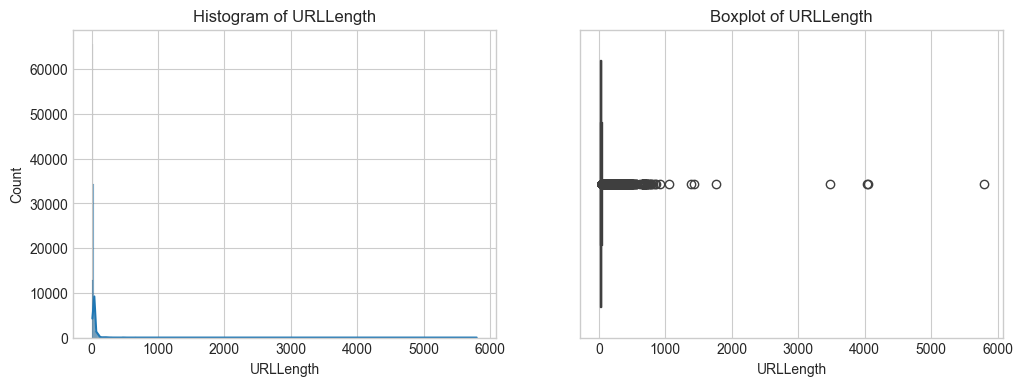

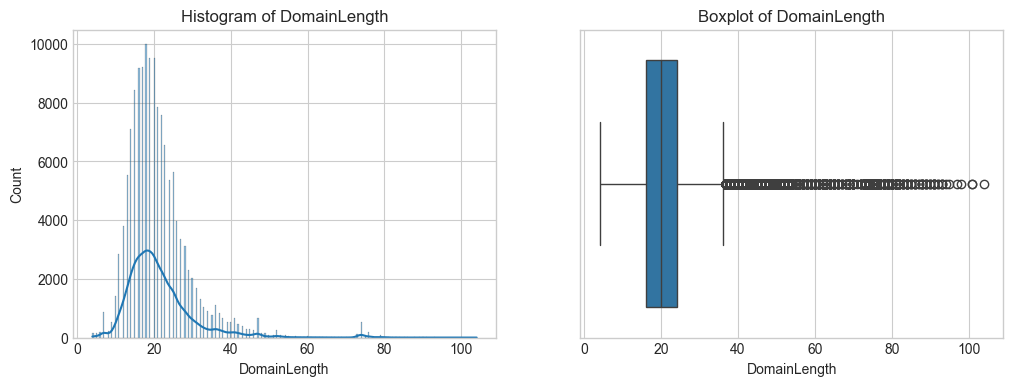

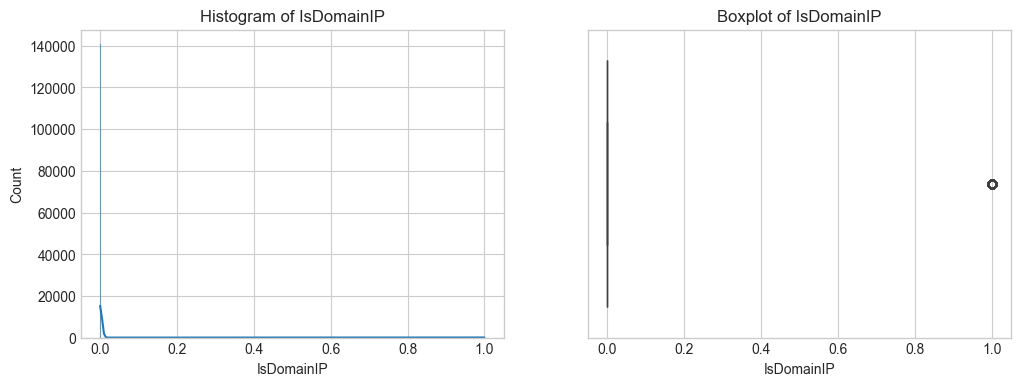

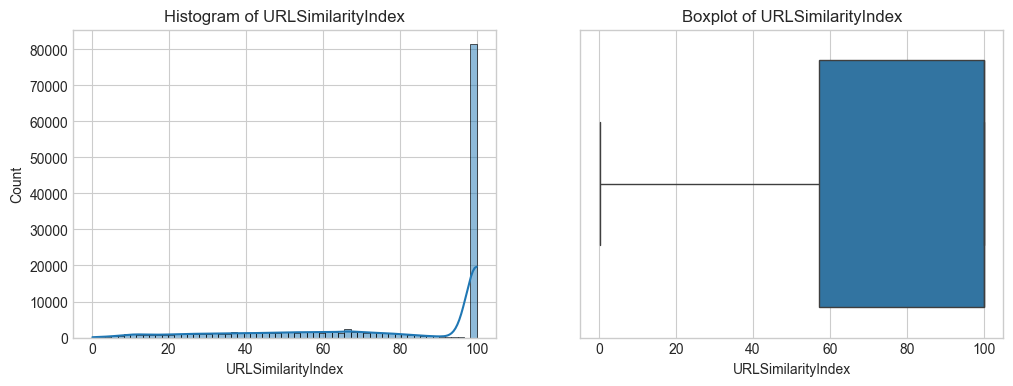

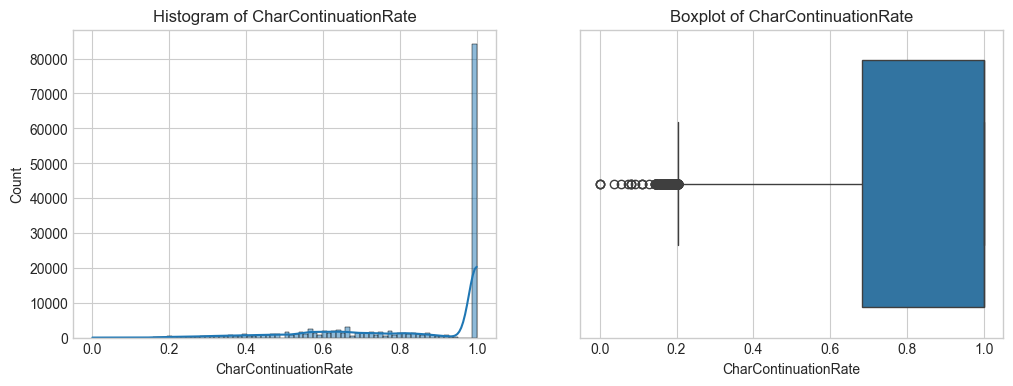

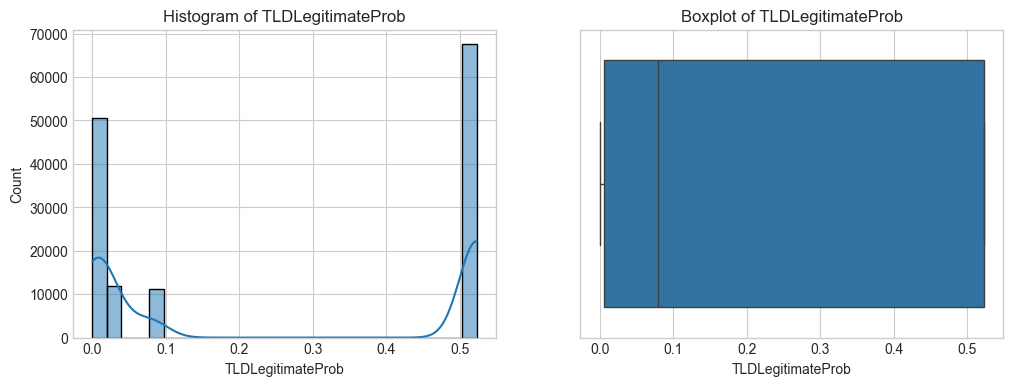

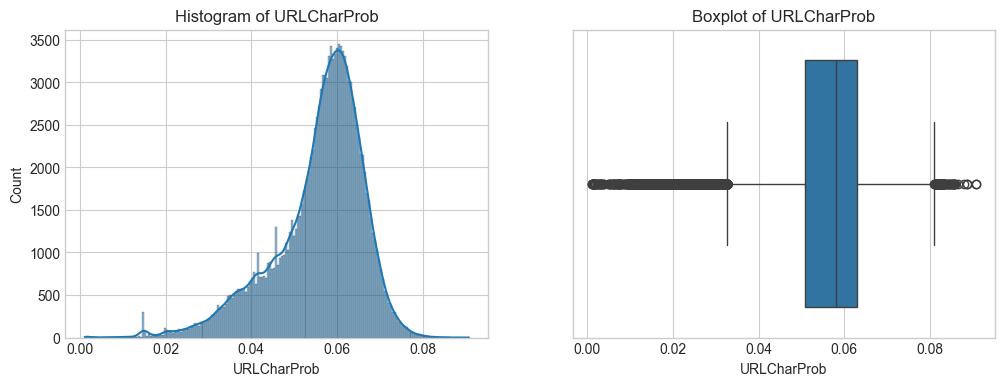

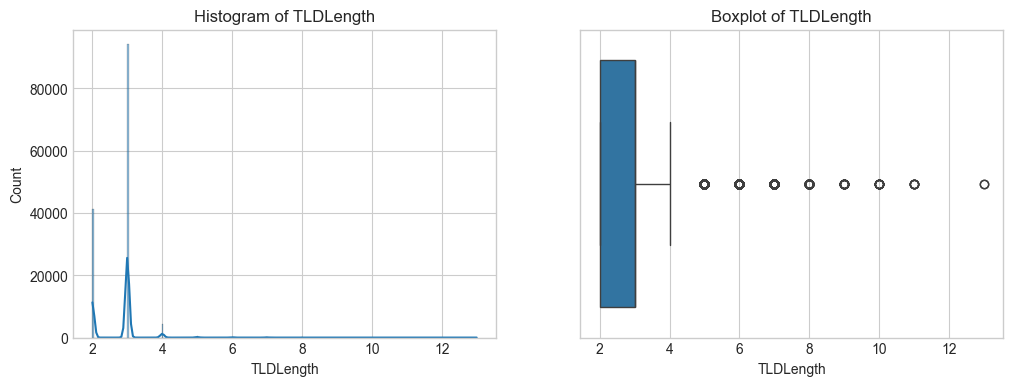

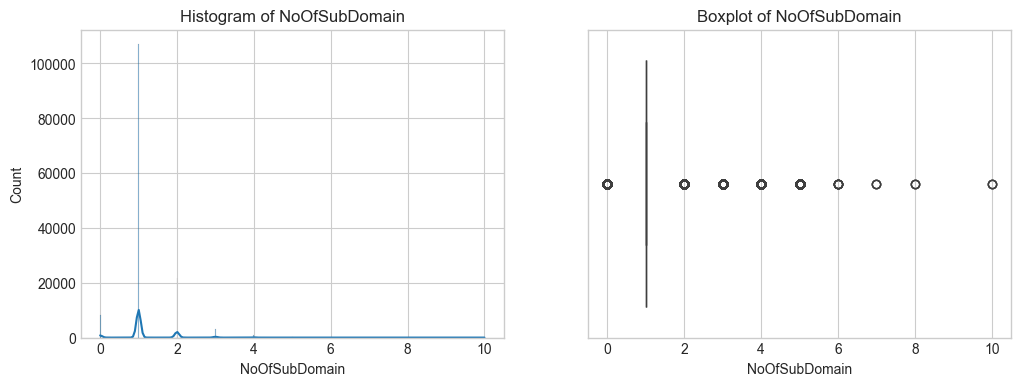

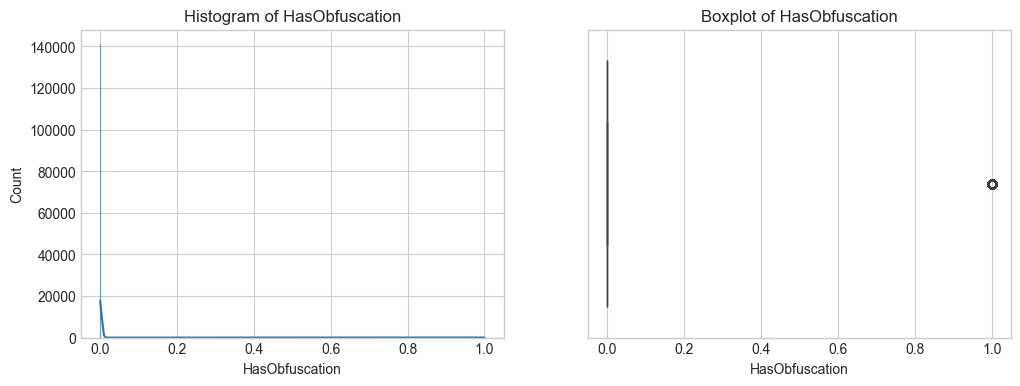

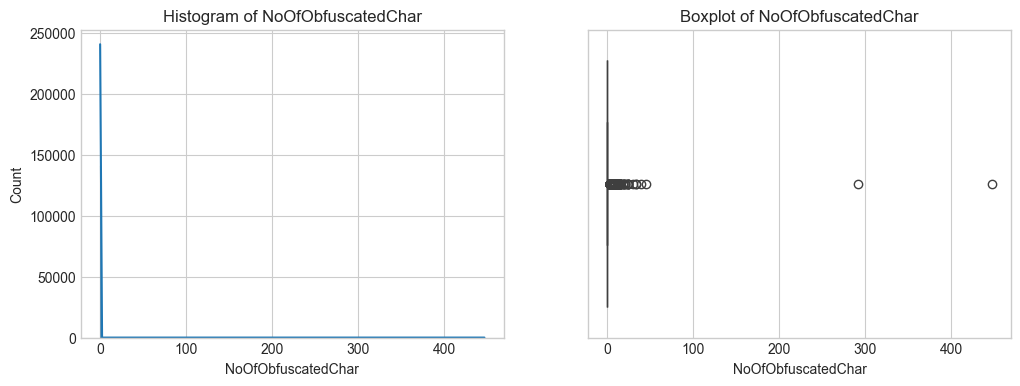

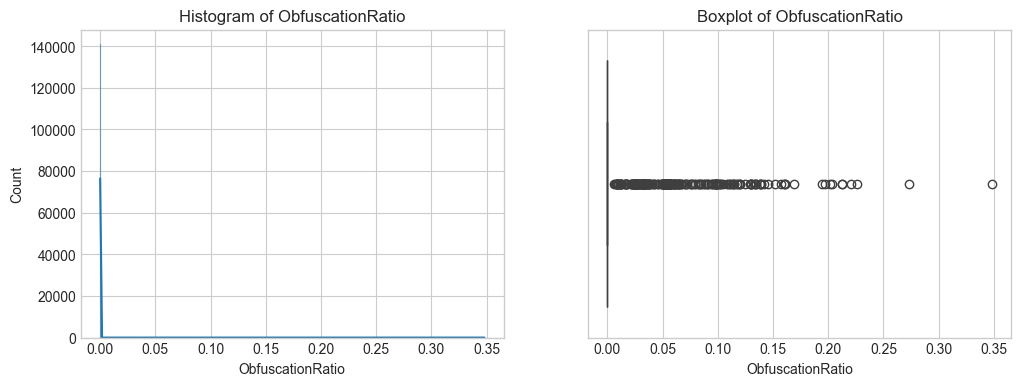

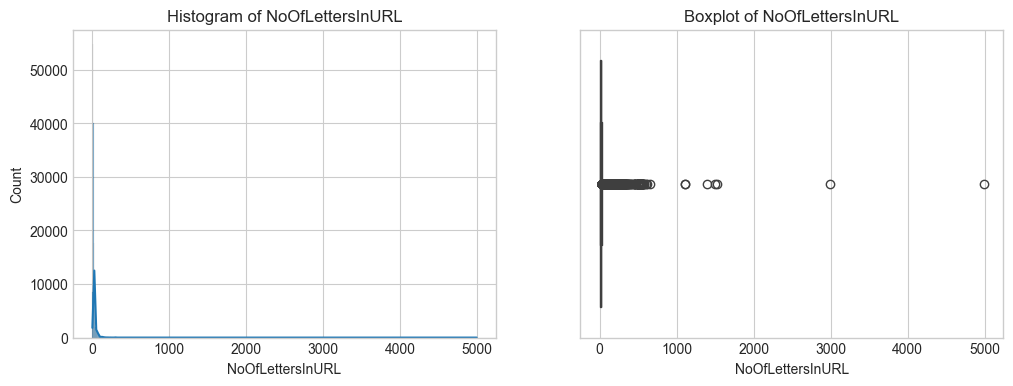

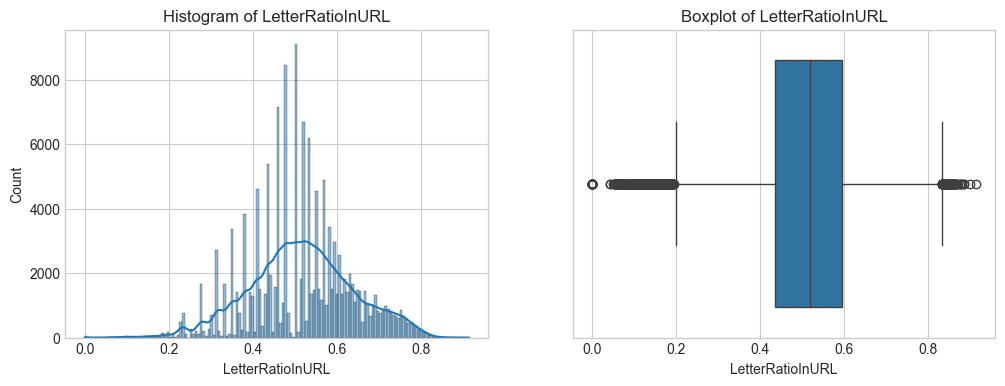

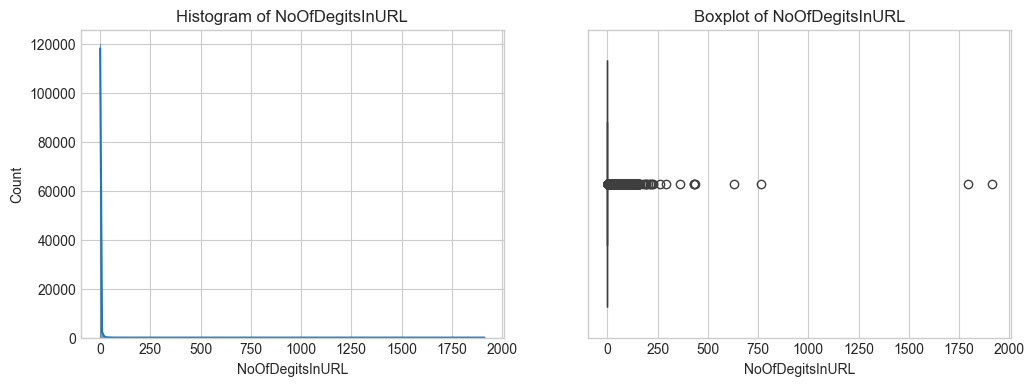

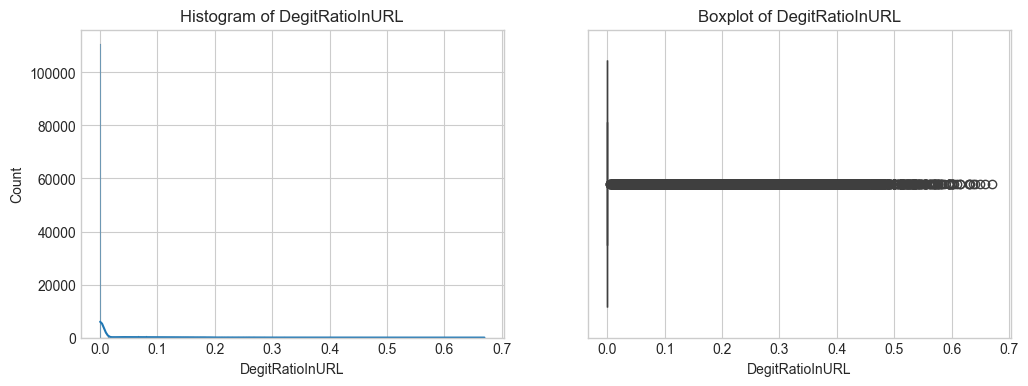

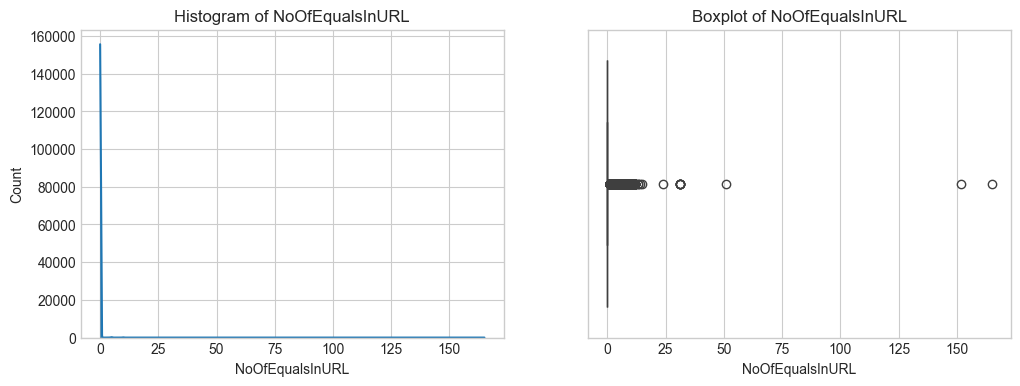

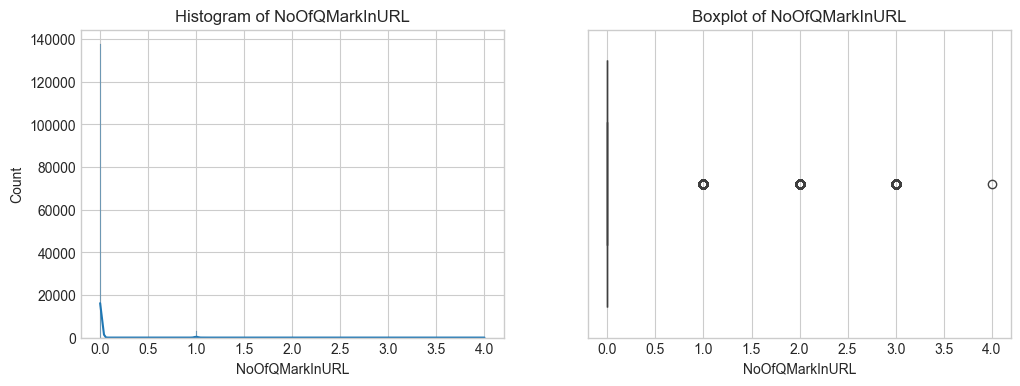

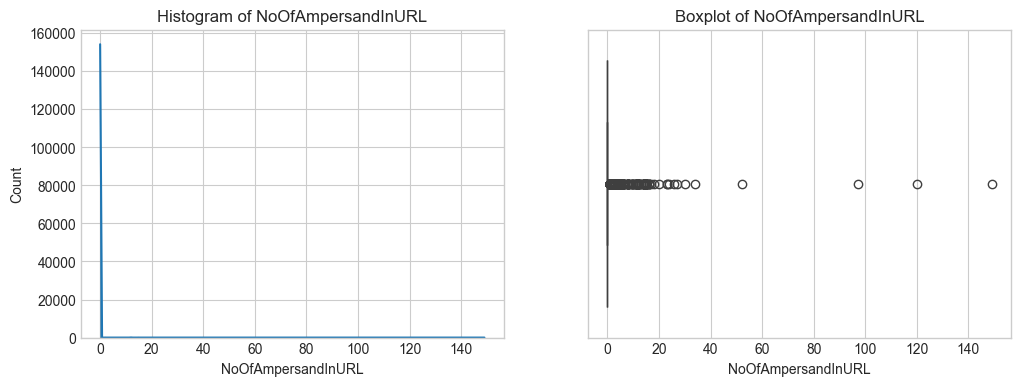

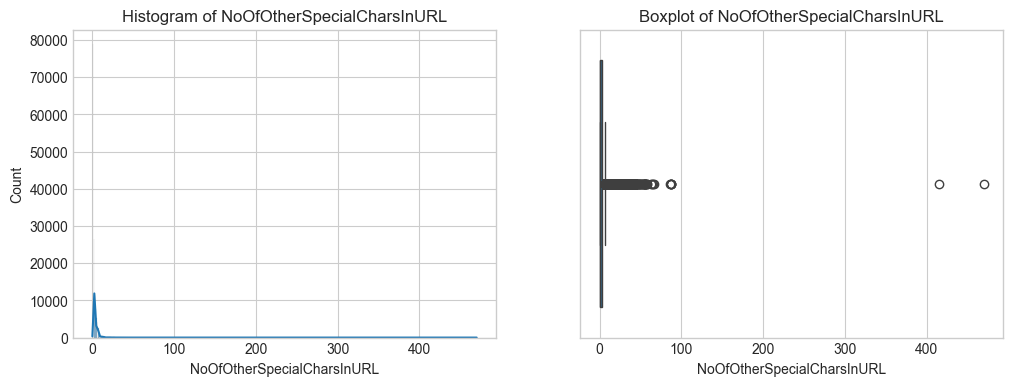

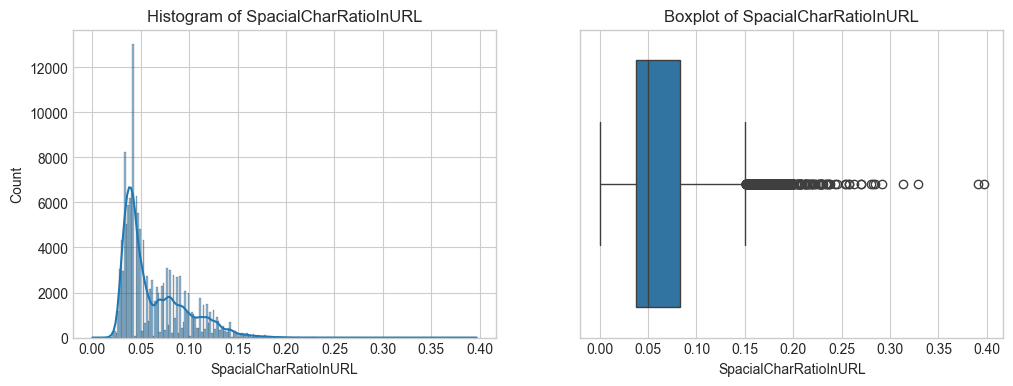

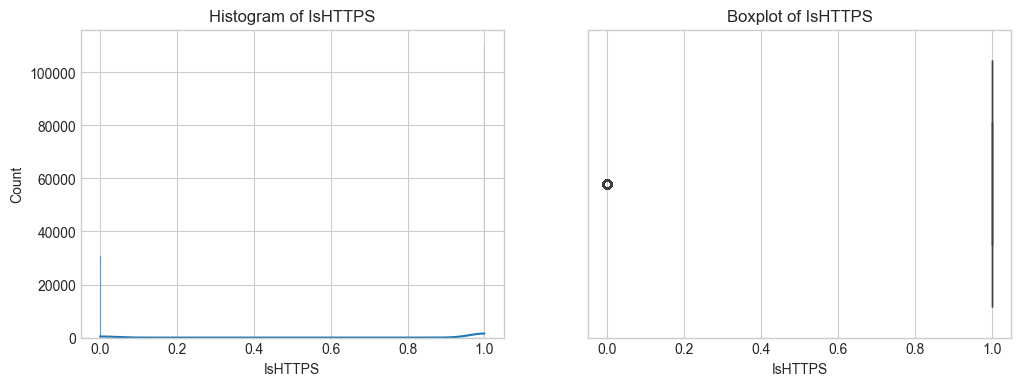

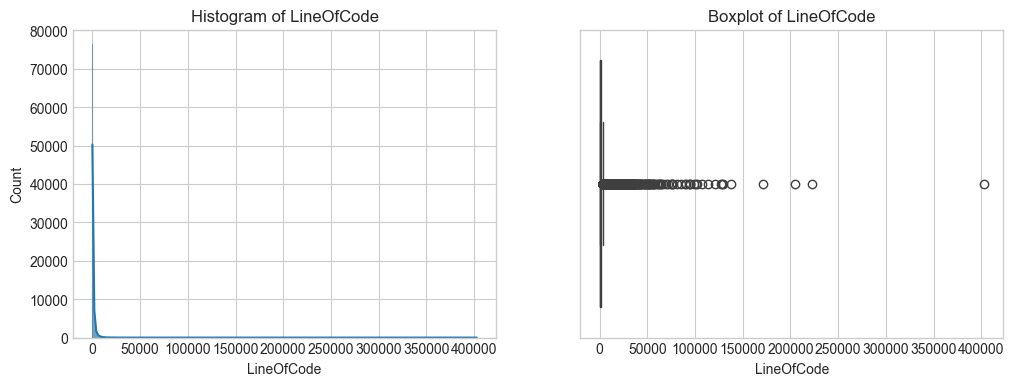

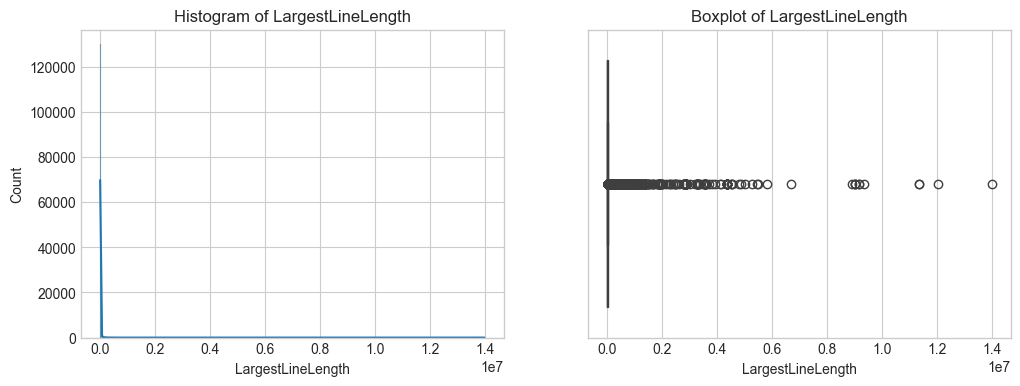

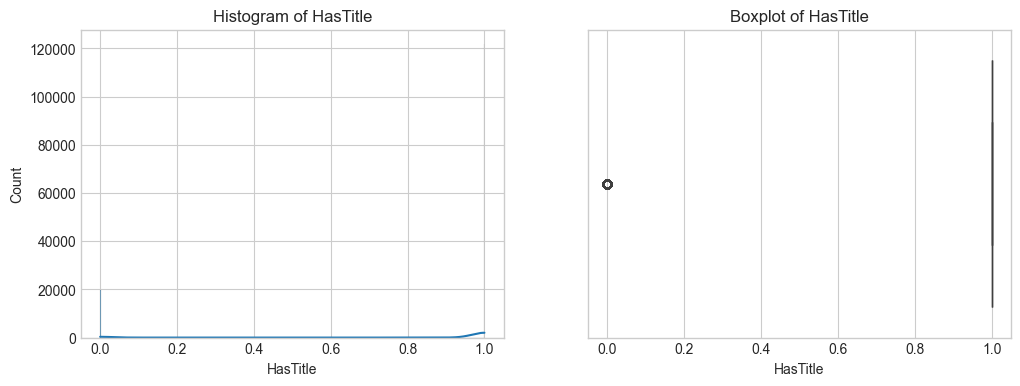

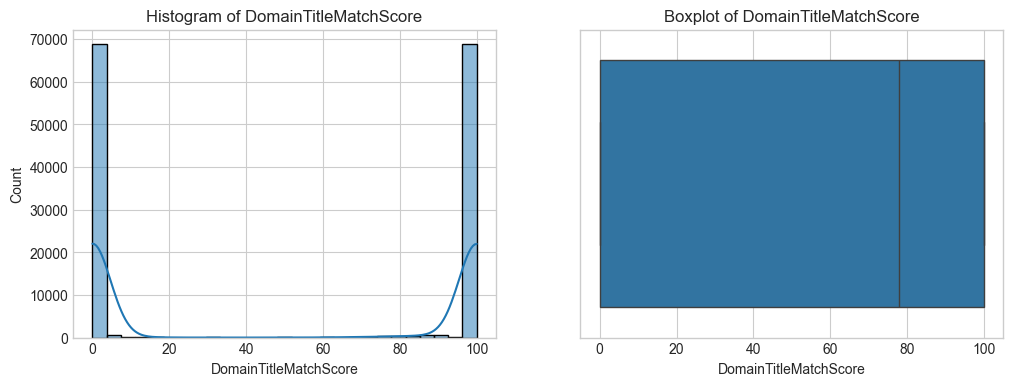

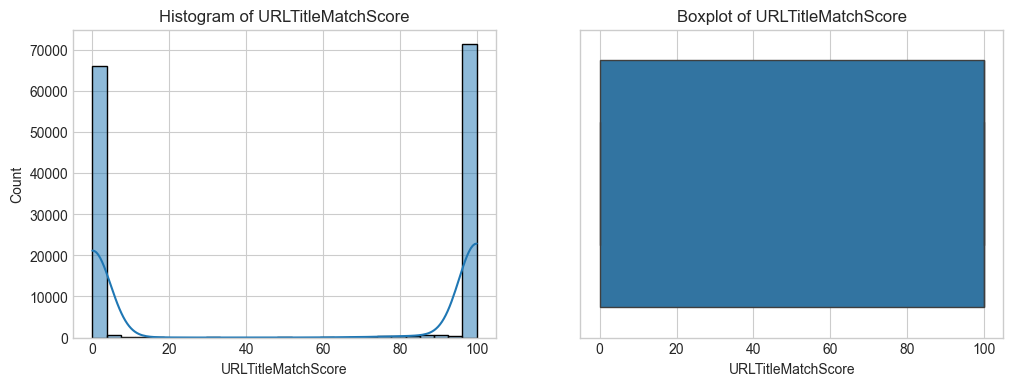

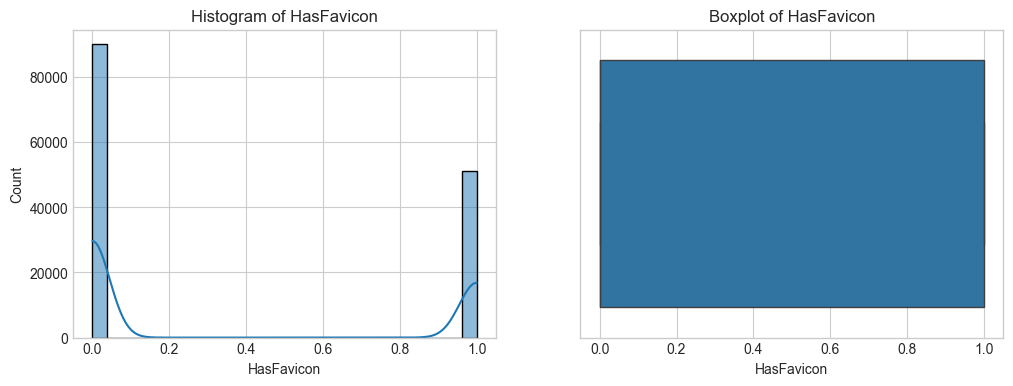

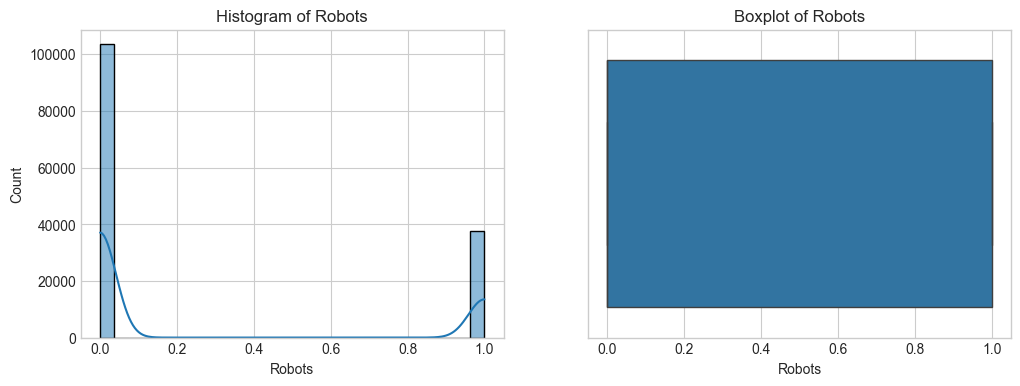

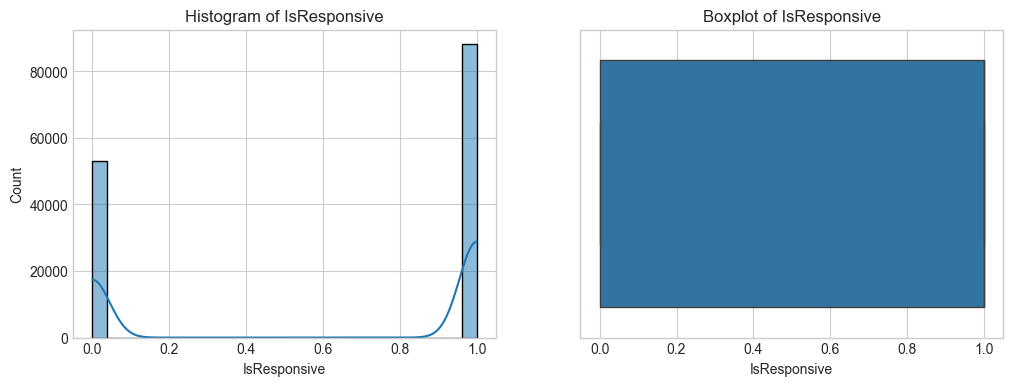

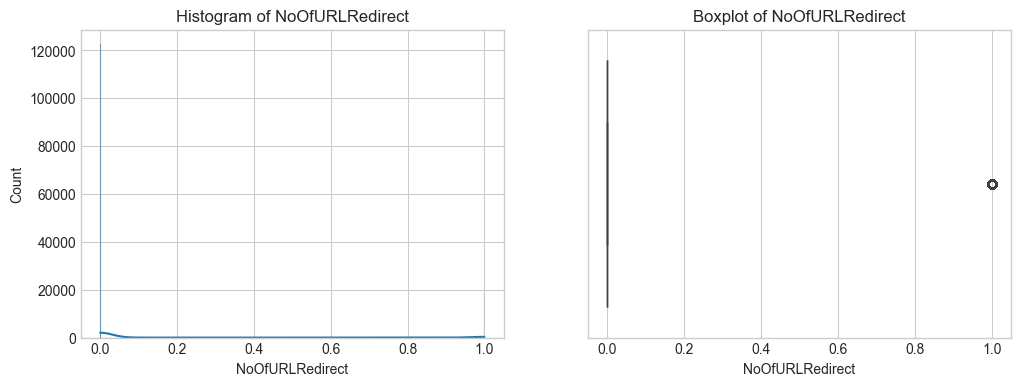

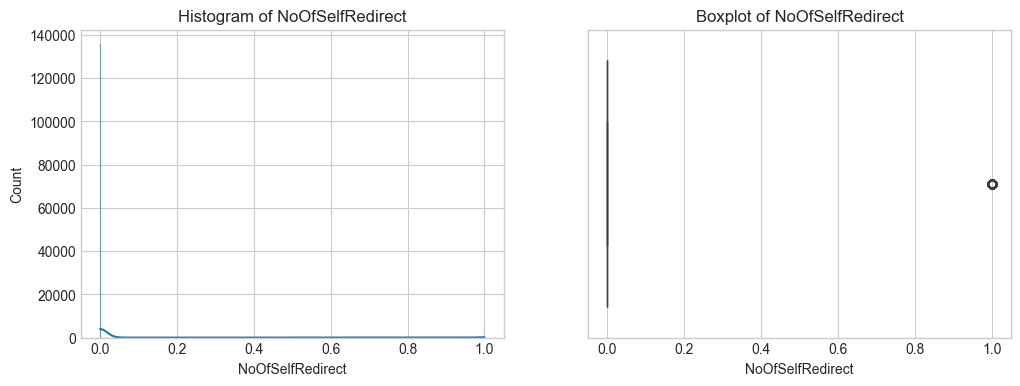

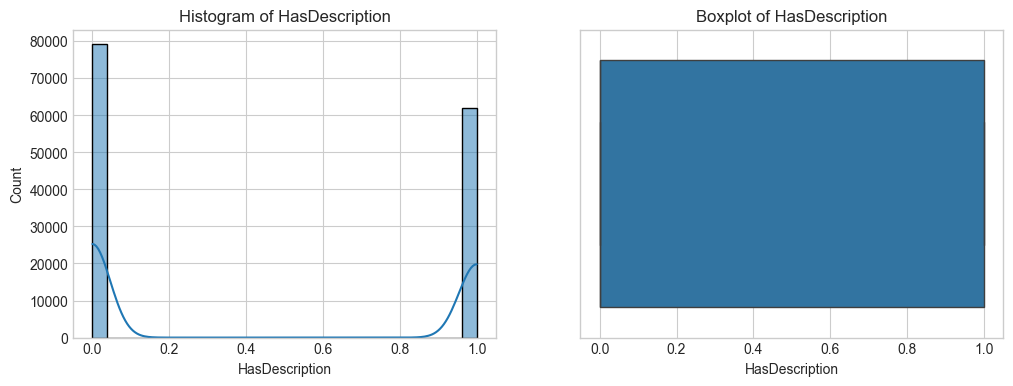

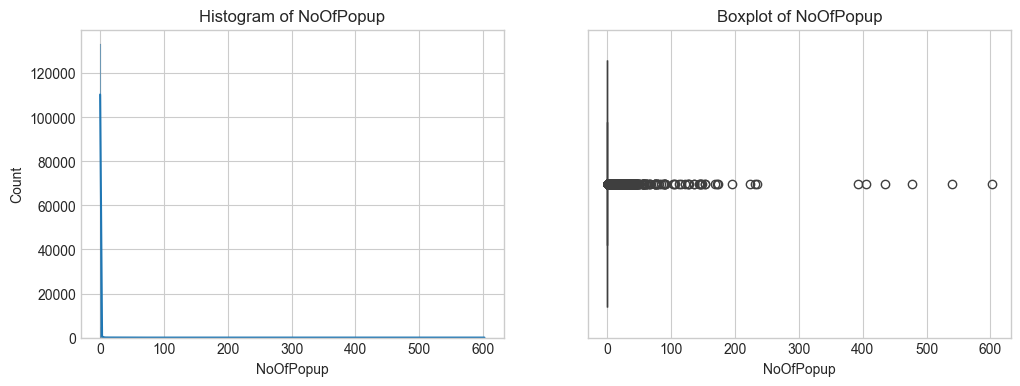

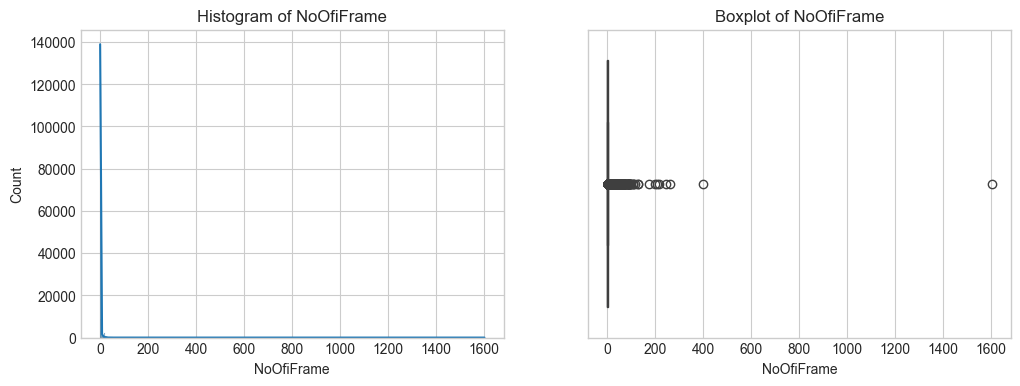

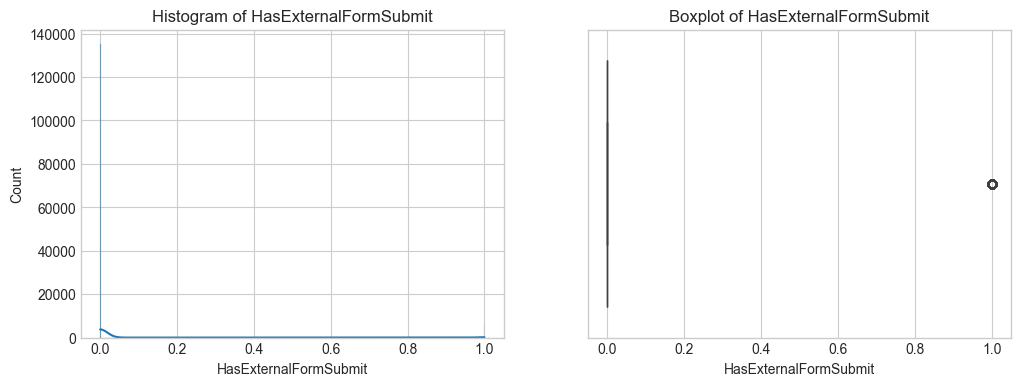

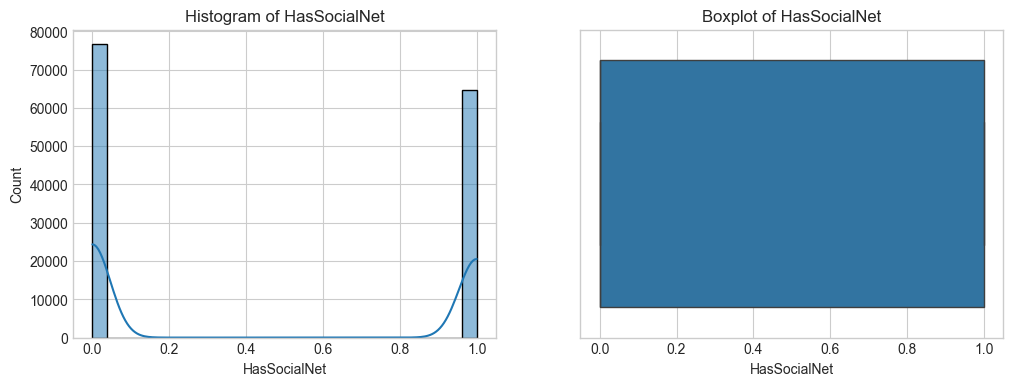

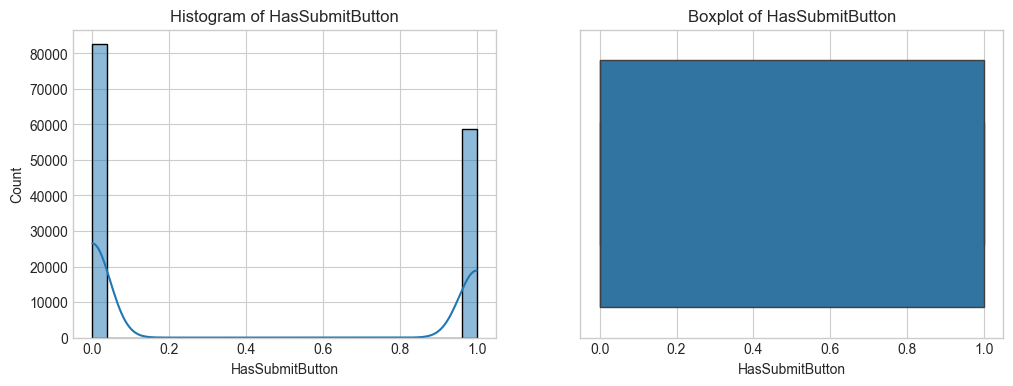

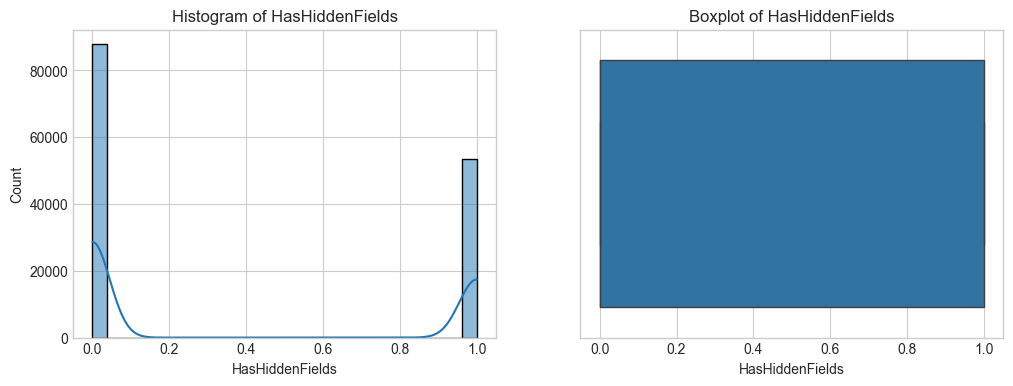

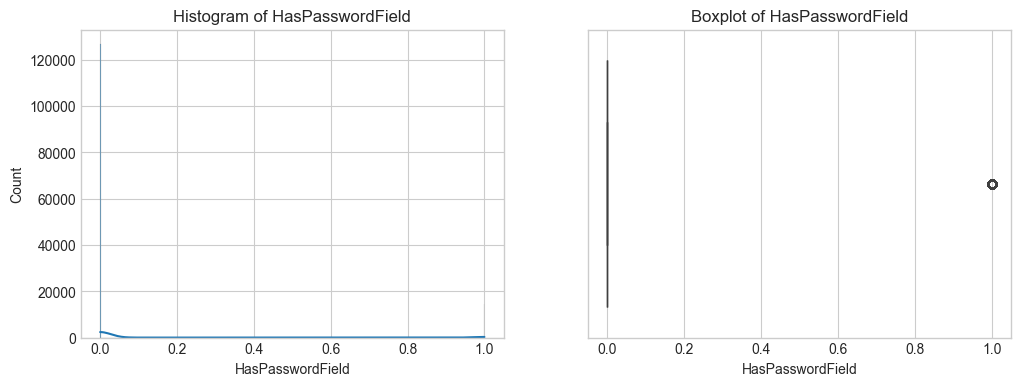

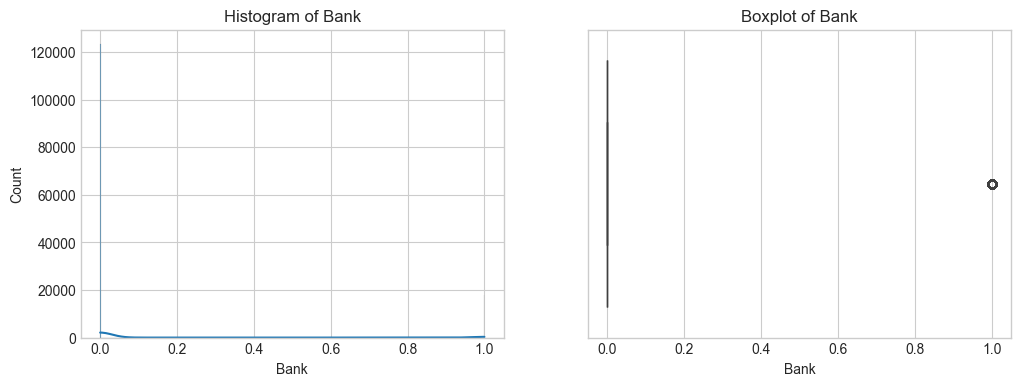

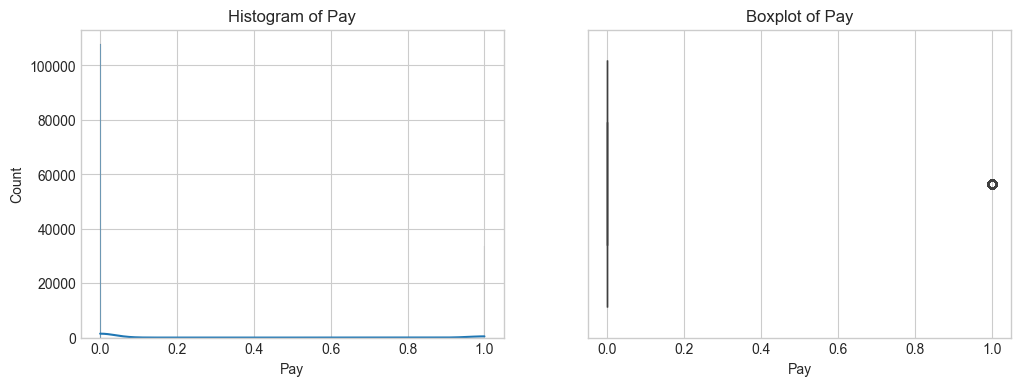

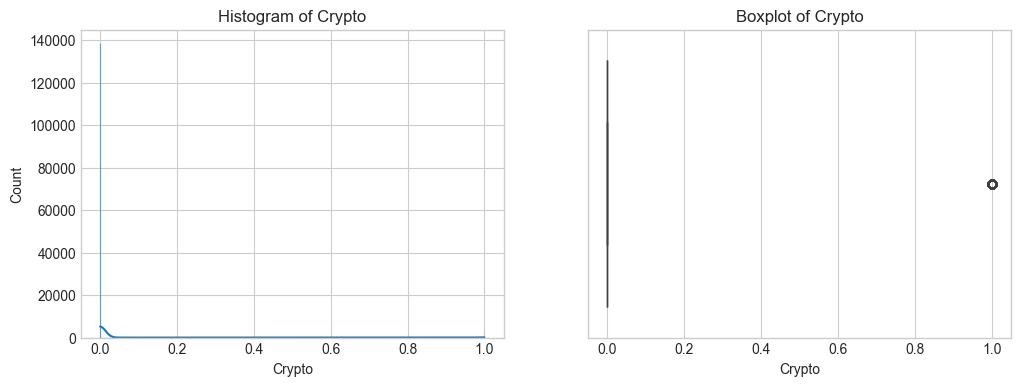

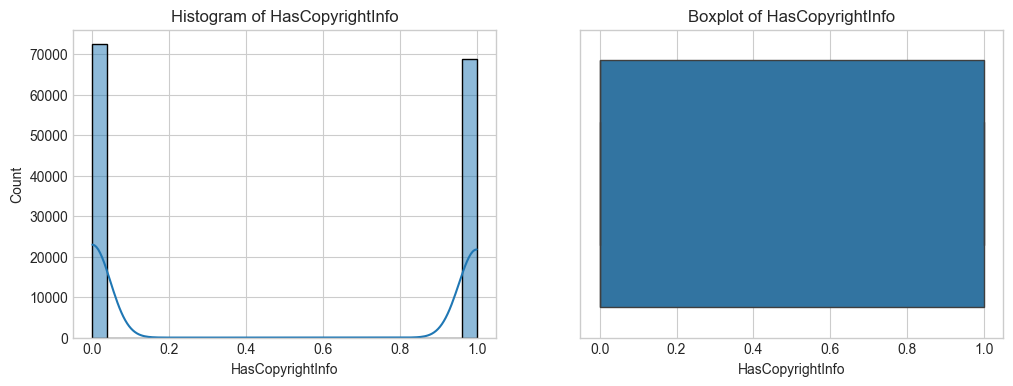

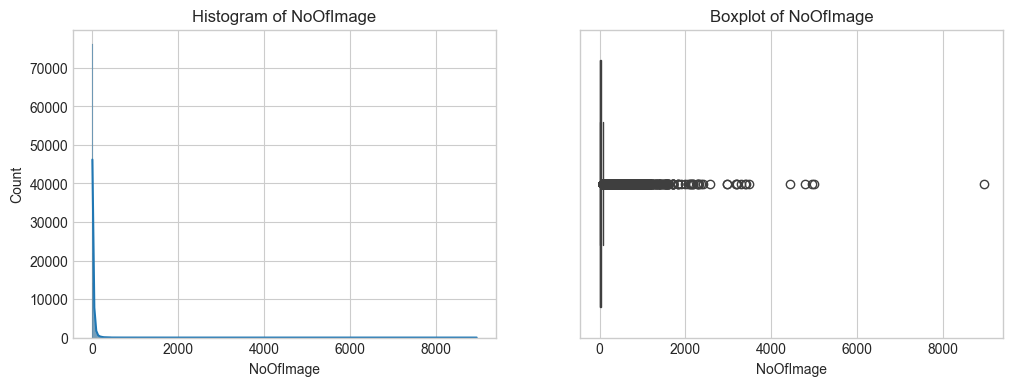

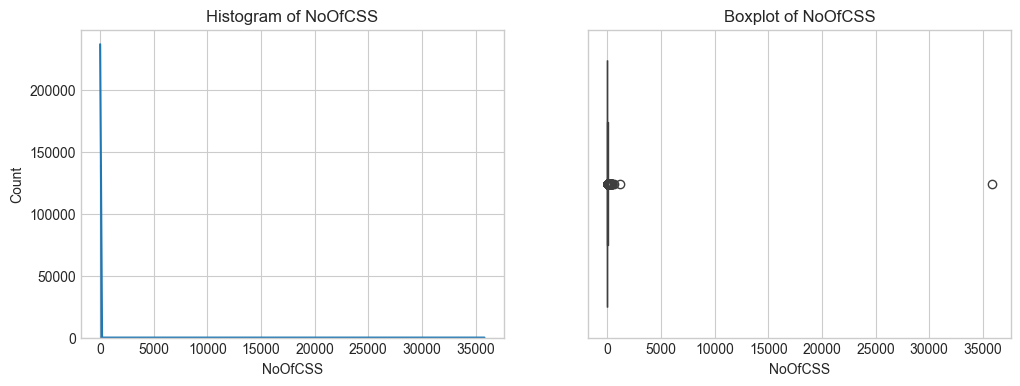

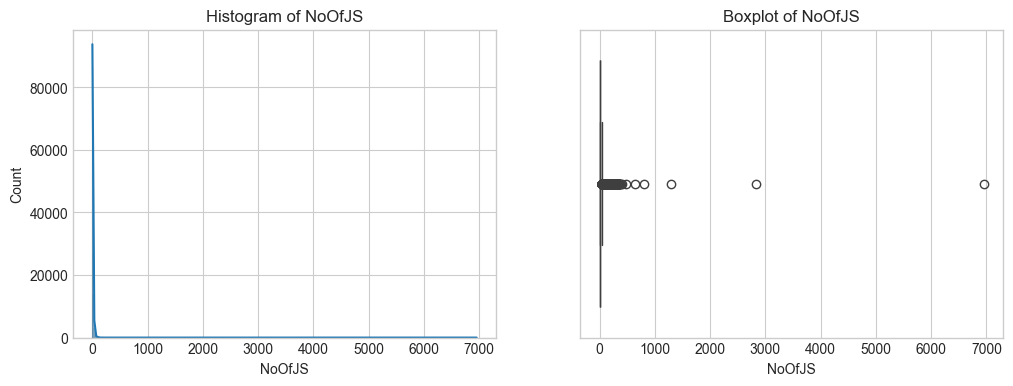

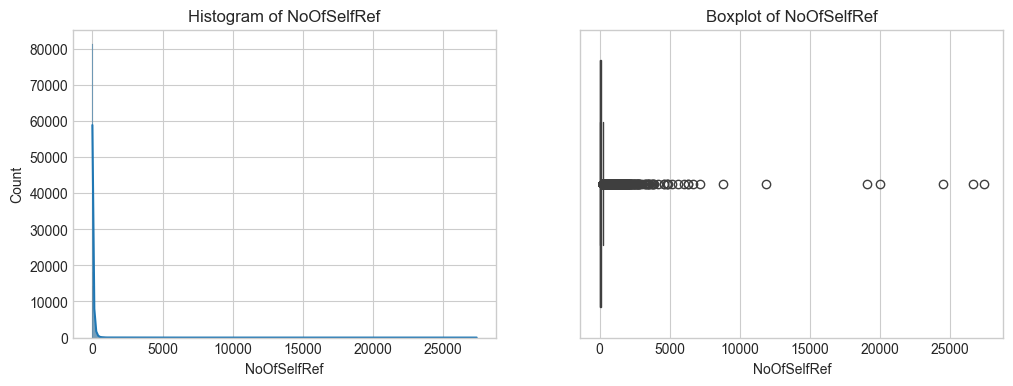

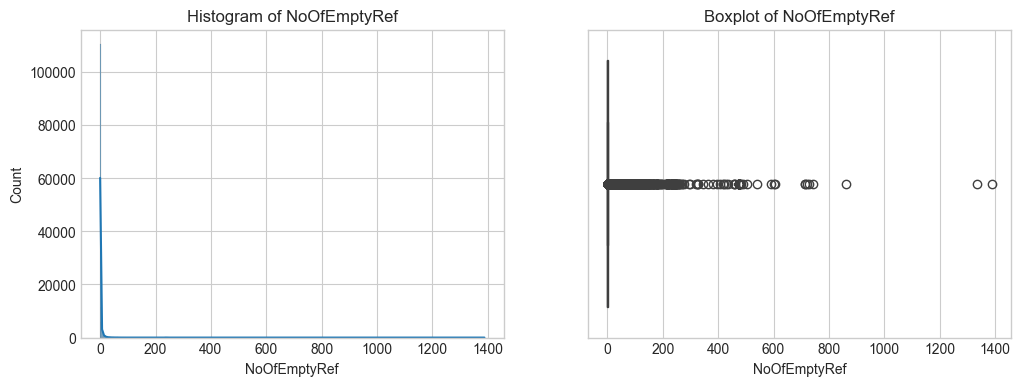

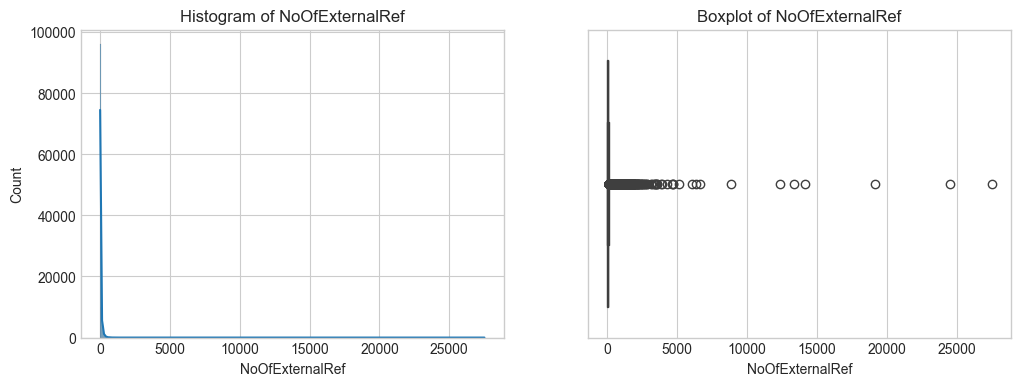

In [44]:
# Histogram and BoxPlot for numerical columns
num_summary = df[num_cols].describe().T
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

Comment: We have outliers for almost every numeric columns except binary columns. We need to look in Feature Engineering part to arrange the data model.

## Outlier Detection

In [45]:
# Univariate Outlier Detection - IQR Method
num_df = df[num_cols].dropna()

print("OUTLIER DETECTION SUMMARY (IQR Method):\n")
for col in num_cols:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = num_df[(num_df[col] < lower_bound) | (num_df[col] > upper_bound)][col]
    outlier_pct = (len(outliers) / len(num_df)) * 100
    
    print(f"{col:30s}: {len(outliers):4d} outliers ({outlier_pct:5.2f}%)")

OUTLIER DETECTION SUMMARY (IQR Method):

URLLength                     : 1116 outliers ( 9.82%)
DomainLength                  :  528 outliers ( 4.65%)
IsDomainIP                    :   42 outliers ( 0.37%)
URLSimilarityIndex            :    0 outliers ( 0.00%)
CharContinuationRate          :    5 outliers ( 0.04%)
TLDLegitimateProb             :    0 outliers ( 0.00%)
URLCharProb                   :  458 outliers ( 4.03%)
TLDLength                     :   95 outliers ( 0.84%)
NoOfSubDomain                 : 2790 outliers (24.55%)
HasObfuscation                :   25 outliers ( 0.22%)
NoOfObfuscatedChar            :   25 outliers ( 0.22%)
ObfuscationRatio              :   25 outliers ( 0.22%)
NoOfLettersInURL              :  925 outliers ( 8.14%)
LetterRatioInURL              :   70 outliers ( 0.62%)
NoOfDegitsInURL               : 2418 outliers (21.27%)
DegitRatioInURL               : 2418 outliers (21.27%)
NoOfEqualsInURL               :  251 outliers ( 2.21%)
NoOfQMarkInURL          

## Correlation Matrix-Heatmap

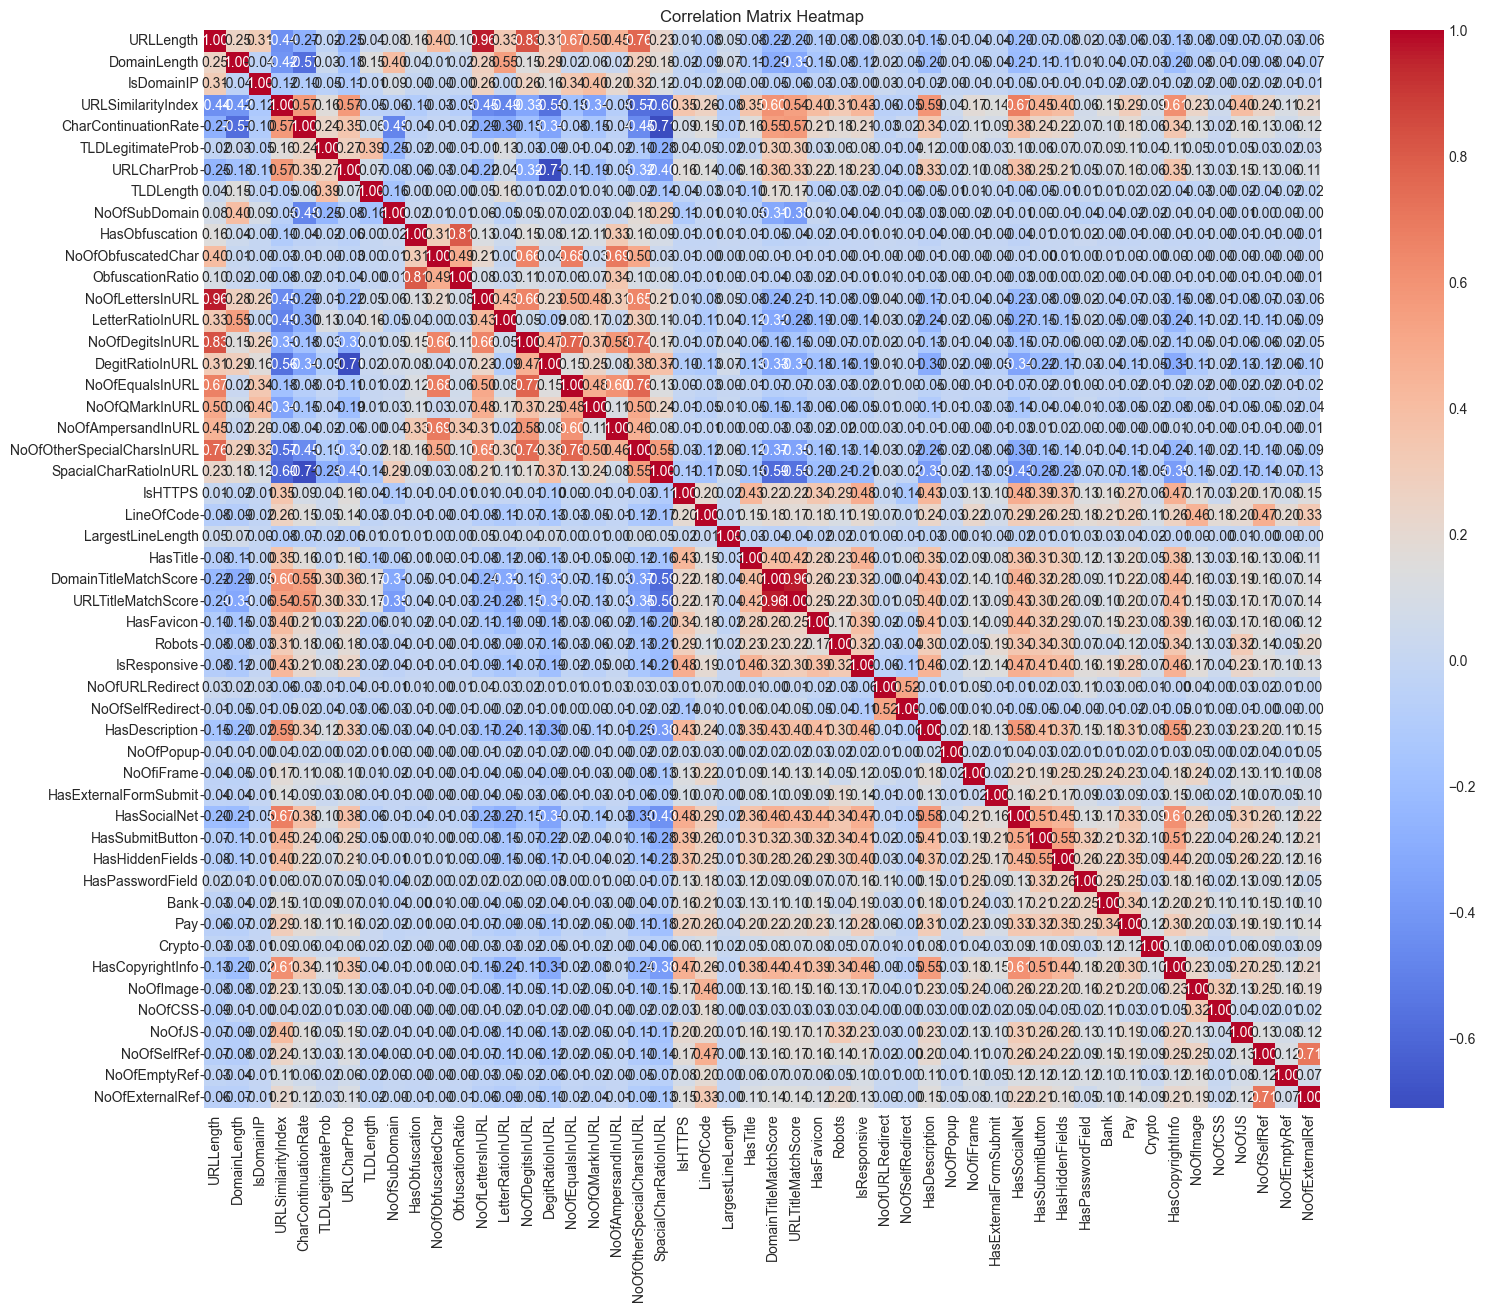

In [46]:
#corr matrix, heat map
corr = df[num_cols].corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Comments: The correlation matrix exhibits significant sparsity, characterized by low correlations across the majority of features (indicated by the prevalence of blue tones). Strong correlations are scarce and clustered within specific subsets of features. This suggests that the features provide independent information, which is advantageous for model performance.

Next, we filter variables using a correlation threshold and plot a focused correlation matrix for better interpretability.

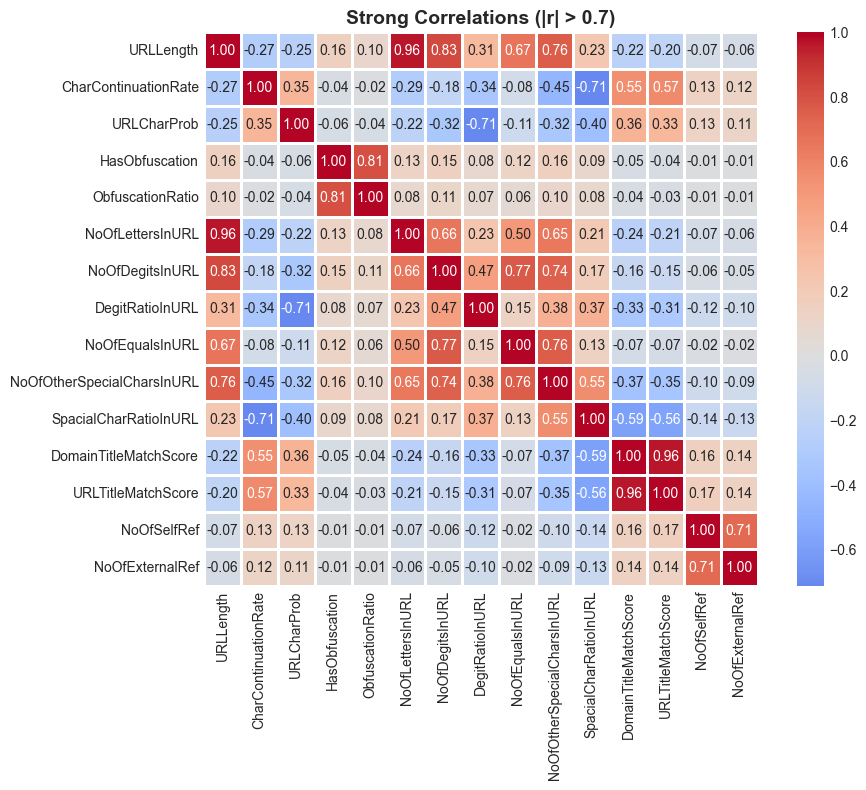

In [47]:
# Filter strong correlations, and visualize
threshold = 0.7
corr_matrix = df[num_cols].corr()

# Find features with strong correlation
mask = (corr_matrix.abs() > threshold) & (corr_matrix != 1.0)
strong_features = corr_matrix.columns[mask.any()].tolist()

# Matrix of strong correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df[strong_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title(f'Strong Correlations (|r| > {threshold})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap above on for label but we want to look closely. 

## Features Correlation Plot on Label

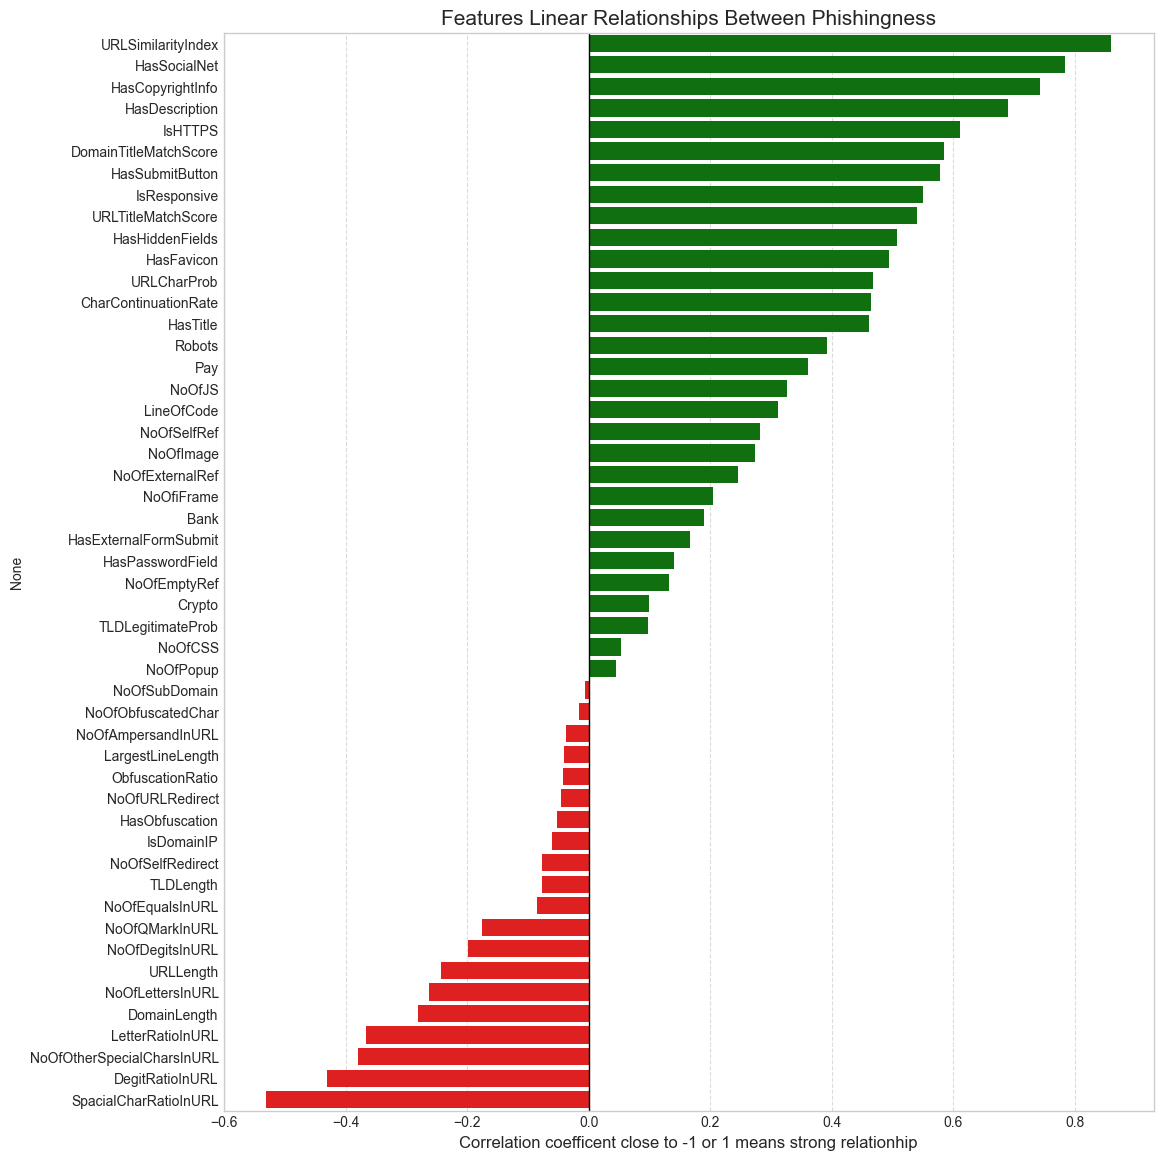

In [48]:
num_df = df[num_cols.tolist() + ['label']]
target_corr = num_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette=colors, legend=False)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comments: Green denotes a positive correlation, while red indicates a negative one. The features displayed are selected based on their strong relationship with the target label. For instance, the presence of social networking content (HasSocialNet) exhibits a strong positive correlation with phishing. This suggests that websites containing more social networking links are significantly more likely to be phishing sites.

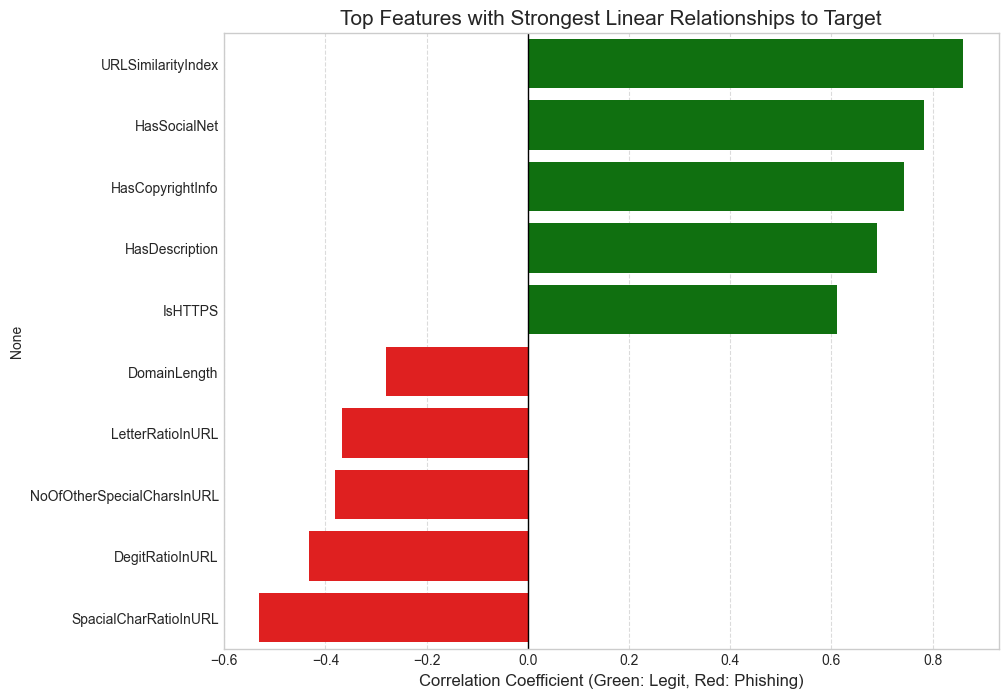

In [49]:
# Calculate correlations
num_df = df[num_cols.tolist() + ['label']]
target_corr = num_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')

# Filter
top_positive = target_corr.head(5)
top_negative = target_corr.tail(5)
top_features = pd.concat([top_positive, top_negative])

# Visualize
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_features.values] 

sns.barplot(
    x=top_features.values, 
    y=top_features.index, 
    palette=colors, 
    hue=top_features.index, 
    legend=False
)

plt.title('Top Features with Strongest Linear Relationships to Target', fontsize=15)
plt.xlabel('Correlation Coefficient (Green: Legit, Red: Phishing)', fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Dealing With UrlSimilarityIndex

         count       mean        std         min         25%         50%  \
label                                                                      
0      60318.0   49.64983  22.559694    0.155574   32.120613   51.455264   
1      80906.0  100.00000   0.000000  100.000000  100.000000  100.000000   

              75%    max  
label                     
0       67.286351  100.0  
1      100.000000  100.0  


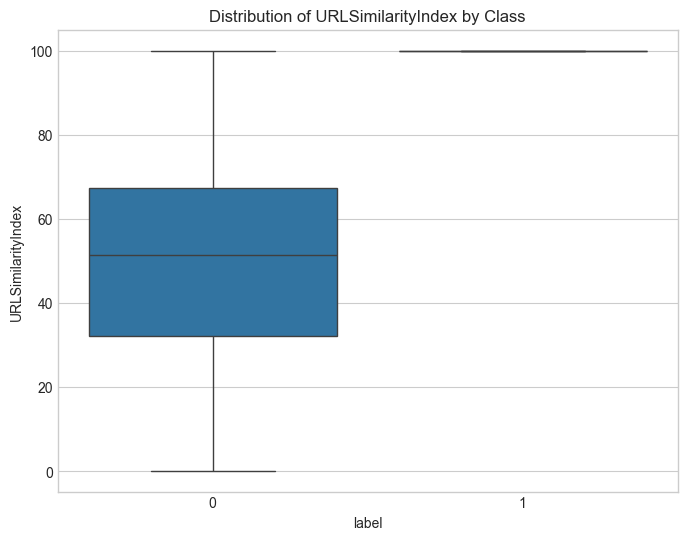

In [50]:
print(df.groupby("label")["URLSimilarityIndex"].describe())

# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='URLSimilarityIndex', data=df)
plt.title('Distribution of URLSimilarityIndex by Class')
plt.show()

Comments: Only with UrlSimilarityIndex column we can detect phising URL's with 0.9758 accuracy. In feature selection part we must extract this column for preventing overfitting. 

## Research Questions

### Question 1

Are phishing URLs more likely to contain digits?

In [51]:
df.groupby("label")["NoOfDegitsInURL"].mean()

label
0    4.265037
1    0.050436
Name: NoOfDegitsInURL, dtype: float64

Comments: We see that legitimate URLs contain almost no digits, while phishing URLs contain about 4 digits on average.

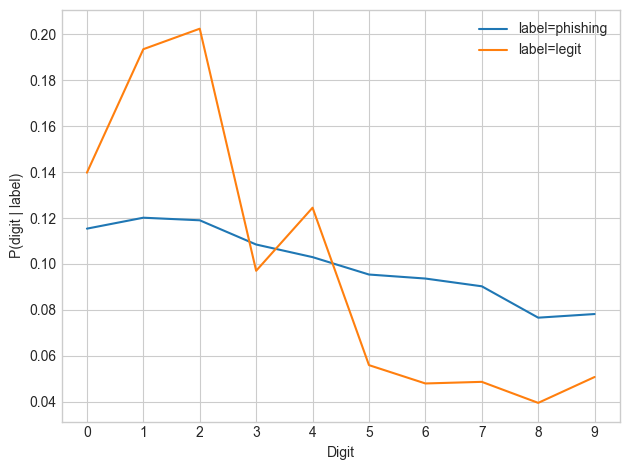

In [52]:
digits = list("0123456789")
digit_counts = (
    df.assign(digit=df["URL"].str.findall(r"\d"))
    .explode("digit")
    .groupby(["label", "digit"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=digits, fill_value=0)
)
digit_probs = digit_counts.div(digit_counts.sum(axis=1), axis=0)

plt.figure()
for label in digit_probs.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

Next, we look at the probability of seeing a digit in the URL in general.

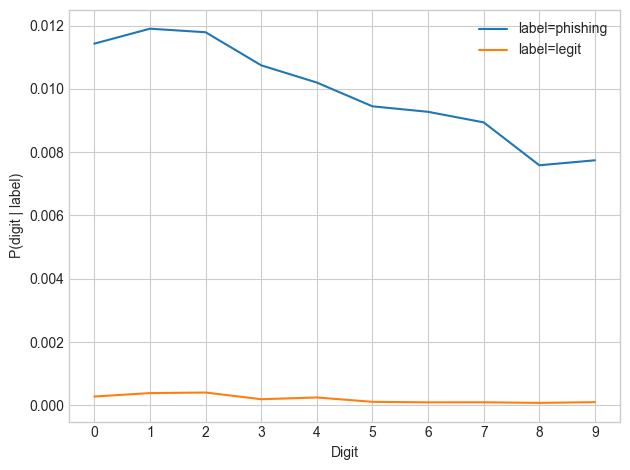

In [53]:
digit_probs_grand = digit_counts.div(df[["label", "URLLength"]].groupby("label").sum()["URLLength"], axis=0)

plt.figure()
for label in digit_probs_grand.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs_grand.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

Conculusion: We see that the it is not very likely to see a digit in a legit URL. However, phishing URLs include disproportionately high number of digits.

### Question 2

Is there a statistically significant relationship between the presence of the 'www' prefix in a domain name and the website's classification as Phishing (0) or Legitimate (1)?

In [54]:
print(df['Domain'].value_counts())

Domain
ipfs.io                         711
docs.google.com                 296
mail.deliverylifesupport.com    236
cloudflare-ipfs.com             224
storageapi.fleek.co             181
                               ... 
www.immediateapparel.com          1
www.climateworks.org              1
www.dozens.com                    1
www.comap.com                     1
www.outrightolds.com              1
Name: count, Length: 133531, dtype: int64


Comment: We examine that normally url domains starts with www, but phising sites may use this domain not inclued subdomain. We look this is true or not?

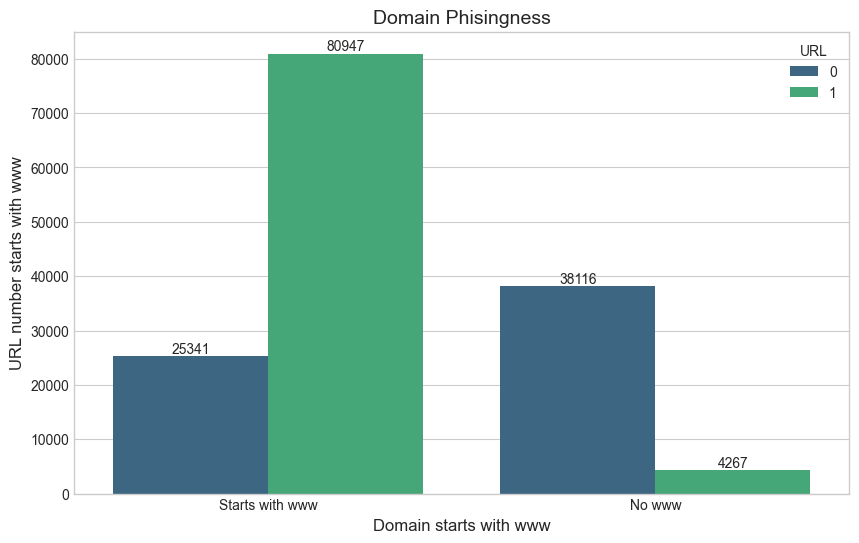

In [55]:
#Creating new column domain starts with www
df['starts_with_www'] = df['Domain'].astype(str).str.startswith('www').map({True: 'Starts with www', False: 'No www'})
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='starts_with_www', hue='label', palette='viridis')
plt.title('Domain Phisingness', fontsize=14)
plt.xlabel('Domain starts with www', fontsize=12)
plt.ylabel('URL number starts with www', fontsize=12)
plt.legend(title='URL')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [56]:
#Statistical Test-Contingency Table
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['starts_with_www'], df['label'])
print(contingency_table)

# Apply test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\np-Value: {p:.5f}")

# Cleaning: Remove temporary columns
df.drop(columns=['starts_with_www'], inplace=True)

label                0      1
starts_with_www              
No www           38116   4267
Starts with www  25341  80947

p-Value: 0.00000


Conclusion: Reject H0. There is meaningul relationship between two variable. 'www' usage, gives informations about site is phishing or not.

-----

### Question 3

Does the variable 'TLDLegitprob' represent the Target Encoding (Mean Encoding) of the categorical 'TLD' feature based on the legitimacy class?

In [57]:
import pandas as pd

# Analyze TLD encoding
tld_analysis = df.groupby('TLD').agg(
    Count=('TLD', 'size'),
    TLDLegitimateProb=('TLDLegitimateProb', 'mean')
).reset_index()

# Check for count encoding: same count, different prob?
collision_count = tld_analysis.groupby('Count')['TLDLegitimateProb'].nunique()
has_collision = (collision_count > 1).sum()

print(f"Total TLDs: {len(tld_analysis)}")
print(f"Count Collisions: {has_collision}")
print(f"\n{'NOT Count Encoding' if has_collision > 0 else 'Likely Count Encoding'}")
print(f"\nTop 10 TLDs:\n{tld_analysis.sort_values('Count', ascending=False).head(10)}")

Total TLDs: 605
Count Collisions: 45

NOT Count Encoding

Top 10 TLDs:
     TLD  Count  TLDLegitimateProb
192  com  67528           0.522907
437  org  11290           0.079963
417  net   4236           0.038420
566   uk   3889           0.028555
101  app   3834           0.001502
188   co   3230           0.005977
326   io   2513           0.012927
212   de   2406           0.032650
481   ru   2318           0.018013
108   au   1744           0.010086


## Structural Data Assesments

### 1- Class Imbalance

In [23]:
print(df['label'].value_counts())
print(f"\nImbalance Ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.2f}:1")

label
1    85214
0    63457
Name: count, dtype: int64

Imbalance Ratio: 0.74:1


Comments: Almost balanced dataset. We can assume class as balance.

### 2- Outliers

Comments: We detect outliers by IQR method above but in phising detection problem outliers are important for detection process. So, we should ignore outliers.

### 3- Normality Check

In [58]:
print("\n4️⃣ NORMALITY CHECK")
from scipy import stats
for col in num_cols:
    _, p = stats.shapiro(df[col].dropna().sample(min(300, len(df))))
    print(f"{col:30s}: {'Normal' if p > 0.05 else 'Non-normal'} (p={p:.4f})")


4️⃣ NORMALITY CHECK
URLLength                     : Non-normal (p=0.0000)
DomainLength                  : Non-normal (p=0.0000)
IsDomainIP                    : Non-normal (p=0.0000)
URLSimilarityIndex            : Non-normal (p=0.0000)
CharContinuationRate          : Non-normal (p=0.0000)
TLDLegitimateProb             : Non-normal (p=0.0000)
URLCharProb                   : Non-normal (p=0.0000)
TLDLength                     : Non-normal (p=0.0000)
NoOfSubDomain                 : Non-normal (p=0.0000)
HasObfuscation                : Non-normal (p=0.0000)
NoOfObfuscatedChar            : Normal (p=1.0000)
ObfuscationRatio              : Non-normal (p=0.0000)
NoOfLettersInURL              : Non-normal (p=0.0000)
LetterRatioInURL              : Normal (p=0.0508)
NoOfDegitsInURL               : Non-normal (p=0.0000)
DegitRatioInURL               : Non-normal (p=0.0000)
NoOfEqualsInURL               : Non-normal (p=0.0000)
NoOfQMarkInURL                : Non-normal (p=0.0000)
NoOfAmpersandIn

c:\Users\ASUS\Desktop\phising_url_project\Phishing-URL--Website--Detection-1\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


HasHiddenFields               : Non-normal (p=0.0000)
HasPasswordField              : Non-normal (p=0.0000)
Bank                          : Non-normal (p=0.0000)
Pay                           : Non-normal (p=0.0000)
Crypto                        : Non-normal (p=0.0000)
HasCopyrightInfo              : Non-normal (p=0.0000)
NoOfImage                     : Non-normal (p=0.0000)
NoOfCSS                       : Non-normal (p=0.0000)
NoOfJS                        : Non-normal (p=0.0000)
NoOfSelfRef                   : Non-normal (p=0.0000)
NoOfEmptyRef                  : Non-normal (p=0.0000)
NoOfExternalRef               : Non-normal (p=0.0000)


Comments: We expect this results from graphs also. Our features distributions are not normal. 

### 4-Multicollinearity

Variance Inflation Factor

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Take numeric columns and clean
df_clean = df[num_cols].select_dtypes(include=[np.number]).dropna()

# Standardize
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Calculate VIF
print("MULTICOLLINEARITY (VIF):\n")

vif_list = []
for i, col in enumerate(df_clean.columns):
    try:
        vif_val = variance_inflation_factor(df_scaled, i)
        vif_list.append({"Feature": col, "VIF": vif_val})
    except Exception as e:
        vif_list.append({"Feature": col, "VIF": np.nan})

vif = pd.DataFrame(vif_list).sort_values("VIF", ascending=False)

problematic = vif[vif["VIF"] > 5].dropna()
if len(problematic) > 0:
    print(problematic.to_string(index=False))
else:
    print("✅ No features with VIF > 5")

print("\nSummary:")
print(f"   Severe (VIF>10): {len(vif[vif['VIF'] > 10])} features")
print(f"   Moderate (5<VIF≤10): {len(vif[(vif['VIF'] > 5) & (vif['VIF'] <= 10)])} features")

MULTICOLLINEARITY (VIF):

                   Feature         VIF
                 URLLength 1512.607068
          NoOfLettersInURL  785.974405
           NoOfDegitsInURL   79.260743
NoOfOtherSpecialCharsInURL   36.422321
     DomainTitleMatchScore   17.524871
        URLTitleMatchScore   16.666406
        URLSimilarityIndex    9.392766
        NoOfObfuscatedChar    9.297676
     SpacialCharRatioInURL    8.831104
          ObfuscationRatio    8.056537
           DegitRatioInURL    6.303859
           NoOfEqualsInURL    6.141141
          LetterRatioInURL    5.348789

Summary:
   Severe (VIF>10): 6 features
   Moderate (5<VIF≤10): 7 features


Comments: We have multicollinerity problem.

### 5-Linearity

For Logistic Regression Box-Tidwell test

In [60]:
from scipy.stats import pearsonr

df_temp = df[list(num_cols) + ['label']].dropna()

def check_linearity(X, transform=None):
    """Check linearity with optional transformation"""
    if transform:
        X = transform(X)
    X_normalized = (X - X.min() + 1) / (X.max() - X.min() + 1)
    X_log_interaction = X_normalized * np.log(X_normalized + 1e-10)
    corr, _ = pearsonr(X_normalized, X_log_interaction)
    return abs(corr) < 0.5

# Original features
linear_orig = [col for col in num_cols if check_linearity(df_temp[col])]

# Log-transformed features
linear_log = [col for col in num_cols if check_linearity(df_temp[col], np.log1p)]

print("LINEARITY CHECK:\n")
print(f"Linear (original): {len(linear_orig)}")
print(f"Linear (log-transformed): {len(linear_log)}")
print(f"\nImprovement: {len(linear_log) - len(linear_orig)} features")

LINEARITY CHECK:

Linear (original): 2
Linear (log-transformed): 9

Improvement: 7 features


Comments: Initially, we had 2 linear features, then we applied a log transformation, resulting in 9 features. We have a dataset with a high density of non-linear features. We continue here to apply the logistic regression model.